# **Chapter 18: 隠れ層とReLU**

## 1本の直線では分けにくい模様を学習する

前回までは、49個の画素から10個の数字スコアへ、1回の線形変換で直接つないでいました。

今回は、その間に25個の隠れ層を置き、ReLUを挟みます。隠れ層は画素のまとまりから特徴を見つけ、ReLUは負の反応を0にして、より複雑な境界を表せるようにします。

つまり、$49 \rightarrow 10$ だったモデルを、$49 \rightarrow 25 \rightarrow 10$ へ拡張します。

Chapter 18では、この新しい構造を学習させ、隠れ層の各ノードがどのような模様に反応するのかを可視化します。


![input to output](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-network.svg)


In [67]:
# テンソルを見やすく表示するライブラリをインストール
!pip install git+https://github.com/HayatoHongo/print_formatted_tensor.git
# PyTorchのテンソルを見やすく表示する関数をインポート
from torch_print_tensor import print_formatted_tensor

  Cloning https://github.com/HayatoHongo/print_formatted_tensor.git to /private/var/folders/jt/5_z36q1n1sg3hfdfbkzytlyh0000gn/T/pip-req-build-w8cd1gh6
  Running command git clone --filter=blob:none --quiet https://github.com/HayatoHongo/print_formatted_tensor.git /private/var/folders/jt/5_z36q1n1sg3hfdfbkzytlyh0000gn/T/pip-req-build-w8cd1gh6
  Resolved https://github.com/HayatoHongo/print_formatted_tensor.git to commit bd6142ed11d910b7f2cf514ec385ab05970b064e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 25.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [68]:
import torch

torch.nn は何度も使うので、ここからは nn という短い名前で呼ぶ

```python
import torch.nn as nn
```

In [69]:
import torch.nn as nn # TODO: import torch.nn as nn
test_model = nn.Linear(1, 1, bias=False) # import が失敗しているとエラーが発生する

`torch.optim` も何度も使うので、ここからは `optim` という短い名前で呼ぶ


```python
import torch.optim as optim
```


In [70]:
import torch.optim as optim  # TODO: import torch.optim as optim
test_optimizer = optim.SGD([test_model.weight], lr=0.1)  # import が失敗しているとエラーが発生する

## **Section 1: 画像と正解ラベルを取り出す**
**Mission: モデルへ渡す入力 $X$ と正解 $y$ を用意する！**

この章では、数字画像を1列に並べた入力を使います。画像は $7 × 7$ ピクセルなので、1枚の入力は $49$ 個の数値です。

データには $1000$ 枚の画像があり、各画像は $49$ 個の画素値として並んでいます。$X$ は画像、$y$ は正しい数字の番号、$Y$ は正解を10個の要素で表した形式です。

モデルが見るのは画像の並びですが、損失を計算するときは正解ラベル $y$ と照合します。


データをダウンロードする


In [71]:
!wget https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/mnist_7x7_shuffled_difficult_1000.pt


--2026-08-07 06:18:42--  https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/mnist_7x7_shuffled_difficult_1000.pt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 246375 (241K) [application/octet-stream]
Saving to: ‘mnist_7x7_shuffled_difficult_1000.pt.2’

mnist_7x7_shuffled_ 100%[===================>] 240.60K  --.-KB/s    in 0.02s   

2026-08-07 06:18:42 (10.2 MB/s) - ‘mnist_7x7_shuffled_difficult_1000.pt.2’ saved [246375/246375]



### データを読む
`torch.load` は、保存済みのデータを読み込む命令です。


保存したデータを読み込みましょう。

```python
出力: data（画像と正解をまとめたデータ）
関数: torch.load
引数: "mnist_7x7_shuffled_difficult_1000.pt"
```


In [72]:
data = torch.load("mnist_7x7_shuffled_difficult_1000.pt")  # TODO: 出力 = 関数(引数)
print("data", data)


data {'X': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), 'y': tensor([3, 1, 4, 0, 2, 3, 0, 7, 8, 0, 9, 2, 4, 9, 8, 2, 8, 6, 3, 2, 0, 2, 2, 1,
        7, 5, 0, 4, 5, 0, 7, 8, 3, 5, 0, 9, 2, 1, 8, 6, 7, 8, 4, 3, 5, 8, 9, 5,
        4, 5, 9, 2, 2, 0, 4, 9, 2, 4, 1, 5, 3, 8, 5, 6, 5, 5, 5, 9, 2, 2, 0, 3,
        0, 5, 3, 7, 1, 8, 0, 4, 3, 9, 2, 7, 2, 7, 3, 9, 6, 6, 3, 4, 8, 1, 9, 8,
        0, 0, 8, 2, 7, 7, 2, 0, 2, 5, 5, 8, 9, 1, 6, 2, 9, 1, 8, 2, 8, 1, 1, 6,
        2, 7, 2, 5, 6, 3, 0, 3, 3, 4, 6, 7, 1, 6, 4, 5, 2, 0, 0, 8, 8, 0, 9, 9,
        0, 1, 2, 1, 3, 6, 4, 2, 9, 6, 5, 5, 1, 7, 8, 2, 9, 5, 3, 4, 1, 0, 3, 1,
        2, 9, 6, 9, 9, 4, 1, 1, 7, 0, 4, 0, 4, 8, 9, 3, 6, 6, 4, 4, 8, 8, 8, 9,
        0, 8, 2, 9, 3, 6, 6, 1, 0, 4, 9, 0, 3, 8, 4, 7, 8, 2, 5, 1, 0, 3, 0, 5,
        6

In [73]:
X = data["X"]  # (1000, 49)
print_formatted_tensor(X, "X")


Tensor Size: [1000, 49]
tensor([
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.03,   0.84,   1.00,   0.07,   0.00,   0.00,   0.00,   0.00,   0.00,   0.04,   0.78,   0.00,   0.00,   0.00,   0.00,   0.90,   0.94,   0.77,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.26,   0.00,   0.00,   0.00,   0.00,   0.70,   0.38,   0.93,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.08,   0.35,   0.61,   0.00,   0.00,   0.00,   0.00,   0.00,   0.55,   0.16,   0.00,   0.00,   0.00,   0.00,   0.00,   0.83,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.99,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.99,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.99,   0.00,   0.00,   0.00,   0.00,   0.82,   0.00,   0.99,

In [74]:
y = data["y"]  # 各クラス100枚
print_formatted_tensor(y, "y")


Tensor Size: [1000]
tensor([
         3.00,   1.00,   4.00,   0.00,   2.00,   3.00,   0.00,   7.00,   8.00,   0.00,   9.00,   2.00,   4.00,   9.00,   8.00,   2.00,   8.00,   6.00,   3.00,   2.00,   0.00,   2.00,   2.00,   1.00,   7.00,   5.00,   0.00,   4.00,   5.00,   0.00,   7.00,   8.00,   3.00,   5.00,   0.00,   9.00,   2.00,   1.00,   8.00,   6.00,   7.00,   8.00,   4.00,   3.00,   5.00,   8.00,   9.00,   5.00,   4.00,   5.00,   9.00,   2.00,   2.00,   0.00,   4.00,   9.00,   2.00,   4.00,   1.00,   5.00,   3.00,   8.00,   5.00,   6.00,   5.00,   5.00,   5.00,   9.00,   2.00,   2.00,   0.00,   3.00,   0.00,   5.00,   3.00,   7.00,   1.00,   8.00,   0.00,   4.00,   3.00,   9.00,   2.00,   7.00,   2.00,   7.00,   3.00,   9.00,   6.00,   6.00,   3.00,   4.00,   8.00,   1.00,   9.00,   8.00,   0.00,   0.00,   8.00,   2.00,   7.00,   7.00,   2.00,   0.00,   2.00,   5.00,   5.00,   8.00,   9.00,   1.00,   6.00,   2.00,   9.00,   1.00,   8.00,   2.00,   8.00,   1.00,   1.00,   6.00,   2.

In [75]:
Y = data["Y"]  # (1000, 10)
print_formatted_tensor(Y, "Y")


Tensor Size: [1000, 10]
tensor([
         [  0.00,   0.00,   0.00,   1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   0.00,   1.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   1.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   1.00,   0.00],
         [  1.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00],
         [  0.00,   0.00,   0.00,   0.00,   0.00,   0.00,

In [76]:
torch.manual_seed(0)


表示の準備ができました。次に、学習に使うデータを手元へ取得します。


## **Section 2: 49 → 10 の1層モデルを復習する**
**Mission: 隠れ層を追加する前の、最も基本的な分類モデルを復習する！**


以前のモデルでは、49個の画素をそのまま10個の数字スコアへ変換していました。間に隠れ層やReLUはありません。


### 1枚の入力を計算する場合

以下では、入力画像が1サンプル（1x49の行列）だった場合の数式と行列積の形です。

### 数式

$$
Y = XW
$$

$X$：入力画像 $(1 \times 49)$　　$W$：重み $(49 \times 10)$　　$Y$：10個の数字スコア $(1 \times 10)$


### 行列積の形

$$
\underbrace{\begin{bmatrix}x_0 & x_1 & \cdots & x_{48}\end{bmatrix}}_{X\ (1\times49)}
\underbrace{\begin{bmatrix}
w_{0,0} & \cdots & w_{0,9} \\
w_{1,0} & \cdots & w_{1,9} \\
\vdots & \ddots & \vdots \\
w_{48,0} & \cdots & w_{48,9}
\end{bmatrix}}_{W\ (49\times10)}
=
\underbrace{\begin{bmatrix}Y_0 & \cdots & Y_9\end{bmatrix}}_{Y\ (1\times10)}
$$

各数字スコアは、49個の画素値と対応する重みの内積です。


![49 to 10 linear network](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-linear-review.svg)


49個の画素値から、10個の数字スコアを計算する線形モデルを作りましょう。バイアスは使いません。

```python
インスタンス: model（49個の入力を10個のスコアへ変換する線形モデル）
クラス: nn.Linear
引数: in_features=49, out_features=10, bias=False
```


In [77]:
import torch.nn as nn
model = nn.Linear(in_features=49, out_features=10, bias=False)  # TODO: インスタンス = クラス(引数)

1枚目の画像を線形モデルに入力して、10個の数字スコアを計算しましょう。

```python
出力: Y_pred（1枚の画像に対する10個の数字スコア）
インスタンス: nn_model
メソッド: forward
引数: X[0]
```


In [78]:
Y_pred = model.forward(X[0])  # TODO: 出力 = インスタンス.メソッド(引数)
print_formatted_tensor("Y_pred", Y_pred)

Y_pred
Tensor Size: [10]
tensor([
         0.15,   0.17,  -0.17,   0.12,   0.06,   0.00,   0.22,  -0.05,  -0.14,   0.15
       ], grad_fn=<SqueezeBackward4>)


### 1000枚の入力をまとめて計算する場合

1000枚の画像をまとめて入力する場合も、使う式は同じです。各画像の49個の画素値に同じ重み $W$ をかけることで、1000枚分の数字スコアを一度に計算します。

### 数式

$$
Y = XW
$$

$X$：1000枚の入力画像 $(1000 \times 49)$　　$W$：重み $(49 \times 10)$　　$Y$：各画像の10個の数字スコア $(1000 \times 10)$


### 行列積の形

$$
\underbrace{\begin{bmatrix}
x_{0,0} & x_{0,1} & \cdots & x_{0,48} \\
x_{1,0} & x_{1,1} & \cdots & x_{1,48} \\
\vdots & \vdots & \ddots & \vdots \\
x_{999,0} & x_{999,1} & \cdots & x_{999,48}
\end{bmatrix}}_{X\ (1000\times49)}
\underbrace{\begin{bmatrix}
w_{0,0} & \cdots & w_{0,9} \\
w_{1,0} & \cdots & w_{1,9} \\
\vdots & \ddots & \vdots \\
w_{48,0} & \cdots & w_{48,9}
\end{bmatrix}}_{W\ (49\times10)}
=
\underbrace{\begin{bmatrix}
Y_{1,0} & \cdots & Y_{1,9} \\
Y_{2,0} & \cdots & Y_{2,9} \\
\vdots & \ddots & \vdots \\
Y_{1000,0} & \cdots & Y_{1000,9}
\end{bmatrix}}_{Y\ (1000\times10)}
$$

1000枚それぞれについて、49個の画素値と対応する重みの内積を計算し、10個の数字スコアを同時に作ります。


1,000枚すべての画像をまとめて線形モデルに入力し、各画像の10個の数字スコアを計算しましょう。

```python
出力: Y_pred（1000枚の画像に対する数字スコア）
インスタンス: model
メソッド: forward
引数: X
```


In [79]:
Y_pred = model.forward(X)  # TODO: 出力 = インスタンス.メソッド(引数)
print_formatted_tensor("Y_pred", Y_pred)

Y_pred
Tensor Size: [1000, 10]
tensor([
         [  0.15,   0.17,  -0.17,   0.12,   0.06,   0.00,   0.22,  -0.05,  -0.14,   0.15],
         [  0.17,  -0.08,  -0.24,   0.05,   0.08,   0.22,   0.26,  -0.32,   0.02,   0.27],
         [ -0.04,   0.53,   0.03,  -0.10,   0.13,   0.03,   0.05,  -0.19,  -0.10,   0.13],
         [  0.06,   0.33,  -0.14,   0.01,   0.22,  -0.19,  -0.19,  -0.02,   0.03,   0.02],
         [  0.06,  -0.07,  -0.02,  -0.15,   0.19,  -0.14,  -0.07,  -0.05,   0.19,   0.33],
         [ -0.06,   0.26,  -0.06,  -0.02,   0.05,   0.18,   0.32,  -0.25,  -0.14,   0.24],
         [  0.35,   0.21,  -0.22,  -0.07,   0.05,  -0.04,   0.06,   0.16,  -0.16,   0.14],
         [  0.06,  -0.07,  -0.13,   0.05,   0.18,   0.24,   0.29,  -0.40,  -0.11,   0.31],
         [  0.21,   0.12,  -0.10,   0.07,   0.02,   0.01,   0.18,  -0.12,   0.07,   0.18],
         [  0.17,   0.18,  -0.07,  -0.09,   0.34,  -0.01,  -0.10,   0.17,  -0.39,  -0.17],
         [ -0.03,   0.01,   0.06,  -0.04,   0.13, 

予測スコアと正解ラベルのずれを、平均クロスエントロピーで測るインスタンスを作りましょう。

```python
インスタンス: criterion（予測の誤差を計算する損失関数）
クラス: nn.CrossEntropyLoss
引数: reduction="mean"
```


In [80]:
criterion = nn.CrossEntropyLoss(reduction="mean")  # TODO: インスタンス = クラス(引数)

損失を小さくする方向へ、モデルの重みを更新するSGDオプティマイザを作りましょう。

```python
インスタンス: optimizer（モデルの重みを更新する最適化手法）
クラス: optim.SGD
引数: [model.weight], lr=0.1
```


In [81]:
optimizer = optim.SGD([model.weight], lr=0.1)  # TODO: インスタンス = クラス(引数)

In [82]:
num_epochs = 10000
for epoch in range(num_epochs):

    # 予測する
    Y_pred = model.forward(X)

    # 損失を計算する
    loss = criterion.forward(Y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print("epoch", epoch, "loss", loss)

epoch 0 loss tensor(2.3451, grad_fn=<NllLossBackward0>)
epoch 1 loss tensor(2.3384, grad_fn=<NllLossBackward0>)
epoch 2 loss tensor(2.3318, grad_fn=<NllLossBackward0>)
epoch 3 loss tensor(2.3252, grad_fn=<NllLossBackward0>)
epoch 4 loss tensor(2.3187, grad_fn=<NllLossBackward0>)
epoch 5 loss tensor(2.3122, grad_fn=<NllLossBackward0>)
epoch 6 loss tensor(2.3058, grad_fn=<NllLossBackward0>)
epoch 7 loss tensor(2.2995, grad_fn=<NllLossBackward0>)
epoch 8 loss tensor(2.2932, grad_fn=<NllLossBackward0>)
epoch 9 loss tensor(2.2870, grad_fn=<NllLossBackward0>)
epoch 10 loss tensor(2.2808, grad_fn=<NllLossBackward0>)
epoch 11 loss tensor(2.2747, grad_fn=<NllLossBackward0>)
epoch 12 loss tensor(2.2686, grad_fn=<NllLossBackward0>)
epoch 13 loss tensor(2.2626, grad_fn=<NllLossBackward0>)
epoch 14 loss tensor(2.2566, grad_fn=<NllLossBackward0>)
epoch 15 loss tensor(2.2506, grad_fn=<NllLossBackward0>)
epoch 16 loss tensor(2.2447, grad_fn=<NllLossBackward0>)
epoch 17 loss tensor(2.2389, grad_fn=<Nll

In [83]:
# 訓練済みモデルで予測する
Y_pred = model.forward(X)
# 予測結果を確率に変換する
Y_pred_prob = torch.softmax(Y_pred, dim=1)
# 確率が最大のクラスを予測結果のクラスとして取得する
Y_pred_class = torch.argmax(Y_pred_prob, dim=1)
# 正解数を計算する
num_correct = torch.sum(Y_pred_class == y)
# 正解率を計算する
accuracy = num_correct / len(y)
print("正解率:", accuracy)

正解率: tensor(0.8290)


## **Section 3: 隠れ層とReLUで特徴を組み合わせる**
**Mission: 画像から10種類の数字らしさを計算するモデルを作る！**


ReLUは負の値を $0$ にするため、直線1本では分けられない複雑な模様も扱えるようになります。最後の層は10個のスコアを出力します。

1. 線形変換層1：49入力 → 25出力  
   $z = XW_1 + b_1$

2. ReLU層：負の値を $0$ にする  
   $h = \operatorname{ReLU}(z)$

3. 線形変換層2：25入力 → 10出力  
   $Y = hW_2 + b_2$
   
$X$：入力画像の画素値　　$W_1, b_1$：最初の層の重みとバイアス　　$h$：隠れ層の出力  
$W_2, b_2$：最後の層の重みとバイアス　　$z$：10個の数字スコア


![hidden-layer nodes](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-hidden-layer-nodes.svg?v=302443c)


<img src="https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/v2samplex0forwardchapter18.png" width="1000" height="640">


それでは始めていきましょう。

まずは1層目から。

![layer 1 focus](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-layer1-focus.svg)


### Layer 1: 49個の画素を25個の値へ変換する

1枚の画像を横1行の行列 $X$ として扱います。最初の層では、49個の画素を25個の値へまとめます。

$$
\underbrace{
\begin{bmatrix}x_0 & x_1 & \cdots & x_{48}\end{bmatrix}
}_{X\ (1\times49)}
\underbrace{
\begin{bmatrix}
w_{0,0} & \cdots & w_{0,24} \\
w_{1,0} & \cdots & w_{1,24} \\
\vdots & \ddots & \vdots \\
w_{48,0} & \cdots & w_{48,24}
\end{bmatrix}
}_{W_1\ (49\times25)}
+
\underbrace{\begin{bmatrix}b_{1,0} & \cdots & b_{1,24}\end{bmatrix}}_{b_1\ (1\times25)}
=
\underbrace{\begin{bmatrix}z_0 & \cdots & z_{24}\end{bmatrix}}_{z\ (1\times25)}
$$

行列積では、$X$ の49個の値と $W_1$ の各列を内積にして、25個の結果を同時に作ります。

特に、Pythonの `z[0]`（数学表記では $z_0$）は、$W_1$ の0列目を使って次のように計算されます。

$$
z_0 = x_0 w^{(1)}_{0,0} + x_1 w^{(1)}_{1,0} + \cdots + x_{48} w^{(1)}_{48,0} + b_{1,0}
$$

つまり、49個の画素それぞれに $W_1$ の0列目の重みを掛け、その49個の積を足し合わせ、最後に `b1[0]` を加えます。Pythonでは次の計算に対応します。

```python
z[0] = X[0] * W1[0, 0] + X[1] * W1[1, 0] + ... + X[48] * W1[48, 0] + b1[0]
```


In [84]:
# 重みの初期値はランダムな値として作成（PyTorchの関数を使用）
W1 = torch.randn(49, 25, requires_grad=True)
# バイアスの初期値はゼロ
b1 = torch.zeros(25, requires_grad=True)

入力画像と第1層の重み・バイアスから、25個の変換前の値を計算しましょう。

```python
出力: z（第1層の変換前の値）
式: X[0] @ W1 + b1
```


In [85]:
z = X[0] @ W1 + b1  # TODO: 出力 = 式
print_formatted_tensor("z", z)

z
Tensor Size: [25]
tensor([
         3.26,   0.86,   1.67,   5.21,   1.39,   3.39,  -2.29,   4.49,   1.52,   5.16,  -0.35,   1.03,   1.00,  -0.35,  -0.77,  -1.73,   3.34,  -0.83,   0.91,   0.61,   3.68,  -2.18,   0.91,  -2.60,   1.14
       ], grad_fn=<AddBackward0>)


![relu 1 focus](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-relu1-focus.svg)


### ReLU 1: 負の値を0にする

次に、25個の出力値をReLU関数に通します。

$$
\underbrace{\begin{bmatrix}h_0 & \cdots & h_{24}\end{bmatrix}}_{h\ (1\times25)}
=
\operatorname{ReLU}\left(
\begin{bmatrix}z_0 & \cdots & z_{24}\end{bmatrix}
\right)
$$


第1層の変換前の値をReLU関数に通し、負の値を0にしましょう。

```python
出力: h（ReLUを通した隠れ層の出力）
関数: torch.relu
引数: z
```


In [86]:
h = torch.relu(z)  # TODO: 出力 = 関数(引数)
print_formatted_tensor("h", h)

h
Tensor Size: [25]
tensor([
         3.26,   0.86,   1.67,   5.21,   1.39,   3.39,   0.00,   4.49,   1.52,   5.16,   0.00,   1.03,   1.00,   0.00,   0.00,   0.00,   3.34,   0.00,   0.91,   0.61,   3.68,   0.00,   0.91,   0.00,   1.14
       ], grad_fn=<ReluBackward0>)


![layer 2 focus](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-layer2-focus.svg)


### Layer 2: 25個の特徴を10個のスコアへ変換する

最後の層では、25個の特徴を10個の数字スコアへ変換します。

$$
\underbrace{\begin{bmatrix}h_0 & \cdots & h_{24}\end{bmatrix}}_{h\ (1\times25)}
\underbrace{
\begin{bmatrix}
w^{(2)}_{0,0} & \cdots & w^{(2)}_{0,9} \\
\vdots & \ddots & \vdots \\
w^{(2)}_{24,0} & \cdots & w^{(2)}_{24,9}
\end{bmatrix}
}_{W_2\ (25\times10)}
+
\underbrace{\begin{bmatrix}b_{2,0} & \cdots & b_{2,9}\end{bmatrix}}_{b_2\ (1\times10)}
=
\underbrace{\begin{bmatrix}Y_0 & \cdots & Y_9\end{bmatrix}}_{Y\ (1\times10)}
$$

特に、クラス0のスコア $Y_0$ は、$W_2$ の **0列目**だけを使って次のように計算されます。

$$
Y_0 = h_0 w^{(2)}_{0,0} + h_1 w^{(2)}_{1,0} + h_2 w^{(2)}_{2,0} + \cdots + h_{24} w^{(2)}_{24,0} + b_{2,0}
$$

つまり、25個の特徴それぞれにクラス0用の重みを掛け、その25個の積をすべて足し合わせ、最後にクラス0のバイアス $b_{2,0}$ を加えます。Pythonでは次の計算に対応します。

```python
Y_pred[0] = h[0] * W2[0, 0] + h[1] * W2[1, 0] + ... + h[24] * W2[24, 0] + b2[0]
```

$X$：入力画像　　$W_1, W_2$：学習する重み　　$b_1, b_2$：バイアス　　$Y$：10個の数字スコア


In [87]:
W2 = torch.randn(25, 10, requires_grad=True)
b2 = torch.zeros(10, requires_grad=True)

隠れ層の25個の値を第2層へ入力し、10個の数字スコアを計算しましょう。

```python
出力: Y_pred（10個の数字スコア）
式: h @ W2 + b2
```


In [88]:
Y_pred = h @ W2 + b2  # TODO: 出力 = 式
print_formatted_tensor("Y_pred", Y_pred)

Y_pred
Tensor Size: [10]
tensor([
         9.21,  -0.06,  -0.20,  -6.47, -11.52, -13.54,  20.72,   1.12, -17.96,   6.51
       ], grad_fn=<AddBackward0>)


1000枚の画像の場合も、計算手順は同じです。

入力`X`が(1000x49)の場合

In [89]:
z = X @ W1 + b1
h = torch.relu(z)
Y_pred = h @ W2 + b2
print_formatted_tensor("Y_pred", Y_pred)

Y_pred
Tensor Size: [1000, 10]
tensor([
         [  9.21,  -0.06,  -0.20,  -6.47, -11.52, -13.54,  20.72,   1.12, -17.96,   6.51],
         [ 12.17,  -5.54, -14.90,  -1.95,  -0.45,  -2.15,  -3.06,   2.31,   2.29,  16.30],
         [ 15.00,  -0.07,  -6.37, -22.08,  -5.14, -24.56,  -0.74,  -0.63, -31.22,  14.80],
         [  8.08, -10.74,  -8.45, -20.64,  -6.86, -19.22,  -1.13,  -1.52, -15.36,   2.20],
         [  7.40,   4.55,  -7.20,  -6.56,  -6.83,  -2.46,   9.10,   0.35, -11.65,  -3.45],
         [  6.60,  -2.61,  -5.17,  -5.11,  -0.66, -10.87,   1.51,  -1.50,  -7.96,  18.43],
         [ 12.95,  -2.92, -13.21,  -7.14,   7.08,  -2.10,  12.89,  18.71, -18.76,  16.48],
         [ 13.72,  -5.18, -14.84,  -2.91,  -2.78,  -5.19,  -0.63,   2.19,  -2.73,  13.58],
         [ 10.99,  -2.97, -11.86, -17.18,  -7.29, -11.70,   9.74,  -1.85, -16.29,  10.34],
         [  9.84, -11.18, -22.62, -18.70,   3.70, -19.65,   8.94,  16.98, -25.37,   8.07],
         [  4.68,  -0.03,  -2.90,  -5.22,  -1.92, 

## **Section 4: モデルをクラスとして定義する**
**Mission: 49 → 25 → 10 の計算を、ひとつのモデルとしてまとめる！**


今までは、49入力 → 10出力の、1層の線形変換モデル $Y=XW$ でした。（バイアスなし）

そのため、`model = nn.Linear(49, 10, bias=False)` という、とても単純なコードでした。

PyTorchのクラス`nn.Linear`をそのまま使えました。

<br>

しかし、今回のような クラスはデフォルトで提供されていません。

そこで、複数の層を順番にまとめたクラスを自作します。

クラスの作り方を忘れてしまった方は、今ここで復習しましょう。


![NeuralNetwork structure](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-class-network.svg)


```python
# モデルのクラスは主に、初期化メソッドと、順伝播のメソッドの2つのメソッドを持ちます。
class NeuralNetwork():
    # クラスの初期化メソッドは、変数を登録します。
    def __init__(self):
        self.W1 = torch.randn(49, 25, requires_grad=True)
        self.b1 = torch.zeros(25, requires_grad=True) 
        self.W2 = # TODO: 出力=式
        self.b2 = # TODO: 出力=式

    # 順伝播のメソッドは、入力を受け取り、出力を返します。
    def forward(self, X):
        # 予測する
        z = X @ self.W1 + self.b1
        h = # TODO: 出力 = 関数(引数). 出力の変数名はh
        Y_pred = # TODO: 出力 = 式
        return Y_pred
```

上記を参考に、クラスのコードを写経してください。

TODO部分は、自分で考えて埋めましょう。

In [90]:
########## WRITE  ########## 
class NeuralNetwork():
    def __init__(self):
        self.W1 = torch.randn(49, 25, requires_grad=True)
        self.b1 = torch.zeros(25, requires_grad = True)
        self.W2 = torch.randn(25, 10, requires_grad=True)
        self.b2 = torch.zeros(10, requires_grad=True)

    def forward(self, X):
        z = X @ self.W1 + self.b1
        h = torch.relu(z)
        Y_pred = h @ self.W2 + self.b2
        return Y_pred











########## WRITE  ########## 

必ず正解と確認してください。

```python
# モデルのクラスは主に、初期化メソッドと、順伝播のメソッドの2つのメソッドを持ちます。
class NeuralNetwork():
    # クラスの初期化メソッドは、変数を登録します。
    def __init__(self):
        self.W1 = torch.randn(49, 25, requires_grad=True)
        self.b1 = torch.zeros(25, requires_grad=True) 
        self.W2 = torch.randn(25, 10, requires_grad=True) # TODO: 出力=式
        self.b2 = torch.zeros(10, requires_grad=True) # TODO: 出力=式

    # 順伝播のメソッドは、入力を受け取り、出力を返します。
    def forward(self, X):
        # 予測する
        z = X @ self.W1 + self.b1
        h = torch.relu(z) # TODO: 出力 = 関数(引数)
        Y_pred = h @ self.W2 + self.b2 # TODO: 出力 = 式
        return Y_pred
```

定義した `NeuralNetwork` クラスから、学習に使うニューラルネットワークを作りましょう。

```python
インスタンス: nn_model（49 → 25 → 10 のニューラルネットワーク）
クラス: NeuralNetwork
引数: なし
```


In [91]:
# PyTorchのランダム性を管理するコード(気にしなくてOK)
torch.manual_seed(0)
# ニューラルネットワークのインスタンスを作成
nn_model = NeuralNetwork()  # TODO: インスタンス = クラス(引数)

インスタンス内部の変数`self.W1`には、`nn_model.W1`でアクセスします。

In [92]:
print_formatted_tensor(nn_model.W1)

Tensor Size: [49, 25]
tensor([
         [ -1.13,  -1.15,  -0.25,  -0.43,   0.85,   0.69,  -0.32,  -2.12,   0.32,  -1.26,   0.35,   0.31,   0.12,   1.24,   1.12,  -0.25,  -1.35,  -1.70,   0.57,   0.79,   0.60,  -1.56,  -0.34,   1.85,   0.75],
         [ -0.59,  -0.17,   0.18,   1.39,   1.59,   0.95,  -0.84,  -0.61,   0.03,  -0.49,   0.25,   0.44,   0.11,   0.64,   0.44,  -0.10,   0.79,  -0.29,   0.05,   0.52,   2.30,  -1.47,  -1.59,  -0.67,   0.87],
         [  1.06,   0.18,  -0.23,  -0.39,   0.54,  -0.40,  -0.45,   0.74,   1.52,   3.41,  -1.53,  -1.23,   1.82,  -0.55,  -0.57,   0.92,   1.11,   1.29,  -1.48,   2.57,  -0.47,   0.34,  -1.63,  -0.55,  -0.48],
         [ -0.50,  -1.07,   1.11,  -0.14,   0.81,  -0.09,   0.69,  -0.84,   0.00,   0.84,  -0.40,   1.04,   0.36,  -0.25,   2.30,  -1.88,  -0.05,  -1.04,  -0.96,   0.03,   0.71,   1.65,  -1.36,   0.34,   0.52],
         [ -2.61,  -1.70,  -0.23,   0.28,   0.25,   0.08,   0.34,   0.45,   0.46,  -0.87,   0.78,  -0.93,  -0.22,  -2.44,  -0

In [93]:
print_formatted_tensor(nn_model.b1)

Tensor Size: [25]
tensor([
         0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00
       ], requires_grad=True)


In [94]:
print_formatted_tensor(nn_model.W2)  # TODO: nn_modelインスタンスのW2を表示する

Tensor Size: [25, 10]
tensor([
         [ -1.30,   0.35,   0.26,  -0.10,   0.28,   0.01,  -0.29,   1.68,   0.94,  -1.47],
         [ -0.04,  -0.70,   0.10,  -0.55,  -0.75,  -1.44,  -0.02,  -1.23,   2.19,   0.22],
         [  1.14,  -2.11,   0.47,   1.44,  -0.11,  -1.33,  -0.04,  -0.14,  -0.55,   0.87],
         [ -0.26,   0.31,  -0.68,  -0.90,  -0.64,   0.11,  -0.51,  -1.08,   1.67,  -0.35],
         [  0.26,  -0.44,  -0.68,  -2.55,   1.55,   1.51,  -0.94,   0.39,  -0.13,   1.53],
         [  1.55,  -0.83,  -1.01,   0.02,   0.34,   0.81,   0.56,  -1.14,   1.12,   0.39],
         [ -0.07,  -0.53,  -0.23,  -1.30,   1.04,  -0.45,   0.23,   0.33,   0.73,   1.99],
         [ -0.75,  -1.12,   1.21,  -0.65,  -0.51,   0.01,   0.98,  -2.11,  -0.69,   0.22],
         [  0.19,  -0.63,   0.52,   0.18,  -0.53,   0.01,  -0.42,  -0.15,   1.32,   0.84],
         [  0.25,  -0.18,  -1.80,   1.08,   0.76,  -0.95,  -0.60,   1.28,   1.19,  -0.62],
         [  1.39,  -0.20,   2.33,   0.82,   0.63,  -0.60,  

In [95]:
print_formatted_tensor(nn_model.b1) # TODO: nn_modelインスタンスのb1を表示する

Tensor Size: [25]
tensor([
         0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00
       ], requires_grad=True)


入力画像すべてをモデルに渡し、各画像に対する10個の数字スコアを予測しましょう。

```python
出力: Y_pred（1000枚の画像に対する10個の数字スコア）
インスタンス: nn_model
メソッド: forward
引数: X
```


In [96]:
Y_pred = nn_model.forward(X)  # TODO: 出力 = インスタンス.メソッド(引数)
print_formatted_tensor("Y_pred", Y_pred)

Y_pred
Tensor Size: [1000, 10]
tensor([
         [ 14.38, -14.93,   7.27,   4.98,   4.45,   1.89,   8.38,  -1.31,   3.07,  12.93],
         [ -0.99, -20.98,   3.76,  -4.09,   1.30,  -5.88,  11.48,  -6.24,  -4.31,  17.38],
         [ 11.05, -17.94,  22.58,   9.38,   0.07,   2.99,   4.42, -13.18,  -2.52,  20.52],
         [  8.04, -13.52,   0.05,   0.28,   5.56,   1.17,  11.84,  -5.38,   3.47,  11.83],
         [  3.53,  -9.64,  -6.81, -14.12,  14.51,   8.25,  10.30,   5.89,  -1.92,  15.82],
         [  8.63, -22.58,  15.77,   5.41,   2.90,  -3.09,   7.10, -11.21,  -0.35,  14.98],
         [ 10.53, -26.79,   1.71,   4.70,   8.50,   0.12,  14.29, -12.73,   8.95,   9.88],
         [  6.66, -20.20,   5.86,   0.18,   3.51,  -2.84,   3.37,  -2.90,  -1.50,  14.35],
         [  8.84,  -7.44,   8.44,  -0.06,   4.11,  -0.52,  10.89,   4.51,  -3.74,  16.96],
         [  8.52, -22.46,   4.46,   2.77,   9.12,  -7.60,  12.22,  -8.97,   1.58,   8.64],
         [  3.05, -10.89,   5.74,  -3.22,   5.52, 

## **Section 5: 訓練開始**


In [97]:
import torch.optim as optim
optimizer = optim.SGD([nn_model.W1, nn_model.b1, nn_model.W2, nn_model.b2], lr=0.1)

モデルは10個のスコアを予測し、Cross Entropyでそのずれを損失 $L$ として計算します。

In [98]:
import torch.nn as nn
criterion = nn.CrossEntropyLoss(reduction="mean")
print(criterion)

CrossEntropyLoss()


In [99]:
loss = criterion.forward(Y_pred, y)
print("loss", loss)

loss tensor(13.0961, grad_fn=<NllLossBackward0>)


ここまでをまとめて、モデルを学習させます。

```python
optimizer.zero_grad()
loss.backward()
optimizer.step()
```

In [100]:
torch.manual_seed(0)

########## NEW ##########
nn_model = NeuralNetwork()
########## NEW ##########
"""DELETE
model = nn.Linear(784, 10, bias=False)
"""
    
criterion = nn.CrossEntropyLoss(reduction="mean")
########## NEW ##########
optimizer = optim.SGD([nn_model.W1, nn_model.b1, nn_model.W2, nn_model.b2], lr=0.1)
########## NEW ##########
"""DELETE
optimizer = optim.SGD([model.weight], lr=1.0)
"""

num_epochs = 10000
for epoch in range(num_epochs):

    # 予測する
    Y_pred = nn_model.forward(X)

    # 損失を計算する
    loss = criterion.forward(Y_pred, y)

    optimizer.zero_grad() # TODO: optimizerの勾配を初期化する
    loss.backward() # TODO: lossに対する勾配(W2,b2,W1,b1の各変数よる偏微分)を逆伝播で計算する
    optimizer.step() # TODO: optimizerのパラメータを更新する

    print("epoch", epoch, "loss", loss)


epoch 0 loss tensor(13.0961, grad_fn=<NllLossBackward0>)
epoch 1 loss tensor(10.6465, grad_fn=<NllLossBackward0>)
epoch 2 loss tensor(9.2834, grad_fn=<NllLossBackward0>)
epoch 3 loss tensor(8.3802, grad_fn=<NllLossBackward0>)
epoch 4 loss tensor(7.7517, grad_fn=<NllLossBackward0>)
epoch 5 loss tensor(7.2793, grad_fn=<NllLossBackward0>)
epoch 6 loss tensor(6.8904, grad_fn=<NllLossBackward0>)
epoch 7 loss tensor(6.5506, grad_fn=<NllLossBackward0>)
epoch 8 loss tensor(6.2430, grad_fn=<NllLossBackward0>)
epoch 9 loss tensor(5.9624, grad_fn=<NllLossBackward0>)
epoch 10 loss tensor(5.7038, grad_fn=<NllLossBackward0>)
epoch 11 loss tensor(5.4652, grad_fn=<NllLossBackward0>)
epoch 12 loss tensor(5.2450, grad_fn=<NllLossBackward0>)
epoch 13 loss tensor(5.0409, grad_fn=<NllLossBackward0>)
epoch 14 loss tensor(4.8507, grad_fn=<NllLossBackward0>)
epoch 15 loss tensor(4.6746, grad_fn=<NllLossBackward0>)
epoch 16 loss tensor(4.5107, grad_fn=<NllLossBackward0>)
epoch 17 loss tensor(4.3580, grad_fn=<N

**`Check Point`**
<label><input type="checkbox">lossが継続的に下がったことを確認した</label>

In [101]:
# 訓練済みモデルで予測する
Y_pred = nn_model.forward(X)
# 予測結果を確率に変換する
Y_pred_prob = torch.softmax(Y_pred, dim=1)
# 確率が最大のクラスを予測結果のクラスとして取得する
Y_pred_class = torch.argmax(Y_pred_prob, dim=1)
# 正解数を計算する
num_correct = torch.sum(Y_pred_class == y)
# 正解率を計算する
accuracy = num_correct / len(y)
print("正解率:", accuracy)

正解率: tensor(0.9390)


**`Check Point`**
<label><input type="checkbox">正解率が単純な線型層の時よりも高いことを確認した</label>

## **Section 6: 学習した重みと隠れ層の特徴を見る**
**Mission: 隠れ層がどんな画像の特徴を見つけたか確かめる！**

モデルの学習が完了しました。ここで、学習済みのパラメータについて解釈を行なっていきます。    
これはモデルの解釈性であり、`Interpretibity` と呼ばれる一大分野にも繋がります。 

まず、大前提として、機械学習済みモデルのパラメータにする解釈は、まず困難であること。    
そして、運良く解釈できたとしても、別の解釈が生まれる可能性が高いこと。この2つに注意してください。

お堅い前置きはここまでにして、実際にモデルのパラメータの中身を見ていきましょう。    
ついに深層学習モデルの本当に面白い部分へとやってきました！



まずは、すべてのパラメータをprintして、中身を見てみます。

In [102]:
print_formatted_tensor(nn_model.W1)


Tensor Size: [49, 25]
tensor([
         [ -1.13,  -1.15,  -0.25,  -0.43,   0.85,   0.69,  -0.32,  -2.12,   0.32,  -1.26,   0.35,   0.31,   0.12,   1.24,   1.12,  -0.25,  -1.35,  -1.70,   0.57,   0.79,   0.60,  -1.56,  -0.34,   1.85,   0.75],
         [ -0.59,  -0.17,   0.18,   1.39,   1.59,   0.95,  -0.84,  -0.61,   0.03,  -0.49,   0.25,   0.44,   0.11,   0.64,   0.44,  -0.10,   0.79,  -0.29,   0.05,   0.52,   2.30,  -1.47,  -1.59,  -0.67,   0.87],
         [  1.01,   0.19,  -0.25,  -0.40,   0.53,  -0.42,  -0.45,   0.88,   1.55,   3.35,  -1.51,  -1.23,   1.87,  -0.75,  -0.57,   0.99,   1.11,   1.29,  -1.48,   2.60,  -0.46,   0.34,  -1.53,  -0.55,  -0.48],
         [ -0.49,  -1.06,   1.11,  -0.15,   0.73,  -0.60,   0.68,  -0.47,  -0.15,   0.84,  -0.64,   0.91,   0.39,  -1.22,   2.50,  -1.10,  -0.24,  -1.04,  -0.96,  -0.37,   1.22,   1.58,  -0.47,   0.34,   0.52],
         [ -2.60,  -1.70,  -0.58,   0.26,   0.23,   0.13,   0.34,   0.80,   0.79,  -0.87,   0.52,  -0.93,  -0.22,  -2.54,  -0

In [103]:
print_formatted_tensor(nn_model.b1)

Tensor Size: [25]
tensor([
         -0.10,  -0.41,  -0.19,  -0.13,  -0.35,   0.27,  -0.53,  -0.07,   0.84,  -0.55,  -0.18,   0.02,   0.05,   0.62,   0.80,   0.08,   0.58,  -0.78,  -0.19,   0.00,  -0.17,  -0.36,   0.74,  -0.80,  -1.17
       ], requires_grad=True)


In [104]:
print_formatted_tensor(nn_model.W2)

Tensor Size: [25, 10]
tensor([
         [ -1.79,   0.96,   1.93,  -0.61,  -0.20,  -0.81,  -0.58,   2.22,   1.23,  -1.99],
         [  0.03,  -0.34,   0.68,  -0.55,  -0.80,  -1.55,  -0.36,  -1.23,   1.86,   0.04],
         [  0.89,  -1.91,  -0.01,   1.84,  -1.22,  -0.61,   0.55,   0.47,  -1.41,   1.04],
         [  0.11,   2.39,  -0.52,  -2.28,  -1.63,   1.61,  -0.89,  -1.02,  -0.60,   0.52],
         [  0.20,  -0.47,  -0.34,  -2.51,   1.25,   1.54,  -0.88,   0.24,  -0.18,   1.65],
         [  1.55,  -1.52,  -1.50,   0.23,   1.27,   0.49,  -0.50,   0.21,   1.39,   0.19],
         [ -0.07,  -0.55,  -0.27,  -1.30,   1.04,  -0.46,   0.17,   0.33,   1.11,   1.73],
         [  0.08,  -0.16,   1.08,   0.11,  -0.96,  -0.22,   1.65,  -3.17,  -0.42,  -1.39],
         [ -1.34,   0.98,  -1.41,  -0.31,  -0.24,   0.53,   0.46,   0.05,   1.64,   0.96],
         [ -0.22,   0.12,  -1.93,   1.30,   1.57,  -1.11,  -0.85,   1.31,   0.91,  -0.70],
         [  1.21,  -2.21,  -0.95,   1.35,   1.50,   2.60,  

In [105]:
print_formatted_tensor(nn_model.b2)

Tensor Size: [10]
tensor([
         -0.05,   0.60,  -0.65,  -0.01,   0.03,  -0.23,   0.68,   0.21,   0.16,  -0.74
       ], requires_grad=True)


ここまでだと、何もわからないですね。

試しに、特定のサンプルを順伝播させてみます。

<img src="https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/chapter18-X3.png" width="250">


ちなみに、最初の結果を示すと、以下のようになります。

<img src="https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/v2samplex0forwardchapter18.png" width="1000" height="640">

In [138]:
x3 = X[3]
print_formatted_tensor(x3)

Tensor Size: [49]
tensor([
         0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.13,   0.94,   0.31,   0.00,   0.00,   0.00,   0.12,   0.73,   0.00,   0.98,   0.00,   0.00,   0.00,   0.94,   0.00,   0.01,   0.66,   0.00,   0.00,   0.77,   0.00,   0.01,   0.88,   0.00,   0.00,   0.00,   0.99,   0.72,   0.64,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00
       ])


In [139]:
# 第1層: (1, 49) @ (49, 25) + (25) -> (25)
z = x3 @ nn_model.W1 + nn_model.b1
print_formatted_tensor(z)

Tensor Size: [25]
tensor([
         -4.26,  -2.24,   4.21,   0.51,  -7.23,   8.19,  -4.29,   8.69,   1.46,   1.53,  -1.97,  -1.38,  -4.85,   5.15,   1.31,  -2.60,   4.95,   1.53,  -4.83,  -0.34,  -1.73,  -4.01,   3.57,  -7.46,  -2.25
       ], grad_fn=<AddBackward0>)


In [140]:
# 活性化層: 負の値を0にする
h = torch.relu(z)
print_formatted_tensor(h)

Tensor Size: [25]
tensor([
         0.00,   0.00,   4.21,   0.51,   0.00,   8.19,   0.00,   8.69,   1.46,   1.53,   0.00,   0.00,   0.00,   5.15,   1.31,   0.00,   4.95,   1.53,   0.00,   0.00,   0.00,   0.00,   3.57,   0.00,   0.00
       ], grad_fn=<ReluBackward0>)


In [141]:
# 第2層: (1, 25) @ (25, 10) + (10) -> (10)
Y_pred = h @ nn_model.W2 + nn_model.b2
print_formatted_tensor(Y_pred)

Tensor Size: [10]
tensor([
         17.56, -12.68,   3.86,  12.34,   3.11,   9.80,   3.44, -20.38,  -4.64,  -7.53
       ], grad_fn=<AddBackward0>)


In [142]:
Y_prob = torch.softmax(Y_pred, dim=0)
print_formatted_tensor(Y_prob)

Tensor Size: [10]
tensor([
         0.99,   0.00,   0.00,   0.01,   0.00,   0.00,   0.00,   0.00,   0.00,   0.00
       ], grad_fn=<SoftmaxBackward0>)


こうして、予測がクラス0になるわけです。

ここからは、クラス0を認識するパラメータ対象を絞って、重みの分析を行います。

下図を参考にして、隠れ層hについて、大きな値をもつノードを5つ探してください。    
上から順に、node0, node1....node24 と並んでいます。

<img src="https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/v2samplex0forwardchapter18.png" width="1000" height="640">


上記の図を見ると、h について大きな値をもつノードは、`node0`~`node24`の25個のノードのうち、

`node2`, `node5`, `node13`, `node16`, `node22` の5つであることがわかります。

In [ ]:
# h[2] が Layer 2 の計算式のどこに対応するかを図で確認する
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

node_index = 2
target_class = 0
h_node2 = h[node_index]
w_node2 = nn_model.W2[node_index, target_class]
bias_class0 = nn_model.b2[target_class]
contribution_node2 = h_node2 * w_node2
partial_score = contribution_node2 + bias_class0

print("h（25個の特徴）")
print_formatted_tensor(h)
print("W2[:, 0]（クラス0へつながる25個の重み）")
print_formatted_tensor(nn_model.W2[:, target_class])
print("選択した計算: h[2] × W2[2, 0] + b2[0]")
print("h[2]                  :", h_node2)
print("W2[2, 0]              :", w_node2)
print("h[2] × W2[2, 0]       :", contribution_node2)
print("b2[0]                 :", bias_class0)
print("部分的なY_pred         :", partial_score)

def draw_boxes(ax, values, selected_index, title, value_format="{:.2f}"):
    values = values.detach().cpu().flatten()
    image = ax.imshow(values.unsqueeze(0), cmap="viridis", aspect="auto")
    ax.add_patch(Rectangle((selected_index - 0.5, -0.5), 1, 1, fill=False, edgecolor="red", linewidth=3))
    ax.set_title(title)
    ax.set_yticks([])
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels([str(i) for i in range(len(values))], rotation=90)
    for i, value in enumerate(values):
        ax.text(i, 0, value_format.format(value.item()), ha="center", va="center", fontsize=7, color="white")
    return image

fig, axes = plt.subplots(4, 1, figsize=(16, 9), gridspec_kw={"height_ratios": [1, 1, 1, 1.2]})
draw_boxes(axes[0], h, node_index, "h: 25 features（赤枠 = h[2]）")
draw_boxes(axes[1], nn_model.W2[:, target_class], node_index, "W2[:, 0]: 25 weights for class 0（赤枠 = W2[2, 0]）")
contributions = h.detach() * nn_model.W2[:, target_class].detach()
draw_boxes(axes[2], contributions, node_index, "h[j] × W2[j, 0]: 25 contributions（赤枠 = h[2] × W2[2, 0]）")
axes[3].axis("off")
axes[3].text(0.05, 0.65, f"h[2] × W2[2, 0] + b2[0]", fontsize=16)
axes[3].text(0.05, 0.28, f"{h_node2.item():.2f} × {w_node2.item():.2f} + {bias_class0.item():.2f} = {partial_score.item():.2f}", fontsize=18, color="red")
axes[3].text(0.65, 0.45, "赤枠の要素だけを取り出した", fontsize=14)
plt.tight_layout()
plt.show()

### `h[2]` と `W2[2, 0]` が取り出している要素

Pythonではインデックスが0から始まるため、`h[2]` は25個の特徴のインデックス2の要素 $h_2$、`W2[2, 0]` はインデックス2行・クラス0列の重み $w^{(2)}_{2,0}$ を表します。`b2[0]` はクラス0のバイアス $b_{2,0}$ です。

$$
Y_0 =\sum_{j=0}^{24} h_j w^{(2)}_{j,0} + b_{2,0}
$$

25個の積のうち、コードでは次の1個の積だけを取り出しています。

$$
\underbrace{\boxed{h_2}}_{h[2]}
\times
\underbrace{\boxed{w^{(2)}_{2,0}}}_{W2[2,0]}
+
\underbrace{\boxed{b_{2,0}}}_{b2[0]}
=
\boxed{h_2 w^{(2)}_{2,0} + b_{2,0}}
$$

元の行列の中では、次の位置です。

$$
\underbrace{
\begin{bmatrix}
h_0 & \cdots & \boxed{h_2} & \cdots & h_{24}
\end{bmatrix}
}_{h\ (1\times25)}
\quad\times\quad
\underbrace{
\begin{bmatrix}
w^{(2)}_{0,0} & \cdots & w^{(2)}_{0,9} \\
\vdots & \ddots & \vdots \\
\boxed{w^{(2)}_{2,0}} & \cdots & w^{(2)}_{2,9} \\
\vdots & \ddots & \vdots \\
w^{(2)}_{24,0} & \cdots & w^{(2)}_{24,9}
\end{bmatrix}
}_{W_2\ (25\times10)}
\quad+\quad\underbrace{\begin{bmatrix}\boxed{b_{2,0}} & \cdots & b_{2,9}\end{bmatrix}}_{b_2\ (1\times10)}
$$

したがって、このコードはクラス0のスコア全体 $Y_0$ ではなく、インデックス2のノードの寄与 $h_2 w^{(2)}_{2,0}$ にバイアス $b_{2,0}$ を加えた値を計算しています。

In [151]:
h_node2 = h[2]
print("h_node2:", h_node2)

Y_pred = h_node2 * nn_model.W2[2, 0] + nn_model.b2[0]
print("Y_pred:", Y_pred)

h_node2: tensor(4.2074, grad_fn=<SelectBackward0>)
Y_pred: tensor(3.6975, grad_fn=<AddBackward0>)


In [ ]:
# h[2] が Layer 2 の計算式のどこに対応するかを図で確認する
# h は1枚の画像に対する25個の隠れ層出力 (25,)、W2は (25, 10) を想定する。
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

node_index = 2
target_class = 0
h_node2 = h[node_index]
w_node2 = nn_model.W2[node_index, target_class]
bias_class0 = nn_model.b2[target_class]
contribution_node2 = h_node2 * w_node2
partial_score = contribution_node2 + bias_class0

print("h（25個の特徴）")
print_formatted_tensor(h)
print("W2[:, 0]（クラス0へつながる25個の重み）")
print_formatted_tensor(nn_model.W2[:, target_class])
print("選択した計算: h[2] × W2[2, 0] + b2[0]")
print("h[2]                  :", h_node2)
print("W2[2, 0]              :", w_node2)
print("h[2] × W2[2, 0]       :", contribution_node2)
print("b2[0]                 :", bias_class0)
print("部分的なY_pred         :", partial_score)

def draw_boxes(ax, values, selected_index, title, value_format="{:.2f}"):
    values = values.detach().cpu().flatten()
    image = ax.imshow(values.unsqueeze(0), cmap="viridis", aspect="auto")
    ax.add_patch(Rectangle((selected_index - 0.5, -0.5), 1, 1, fill=False, edgecolor="red", linewidth=3))
    ax.set_title(title)
    ax.set_yticks([])
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels([str(i) for i in range(len(values))], rotation=90)
    for i, value in enumerate(values):
        ax.text(i, 0, value_format.format(value.item()), ha="center", va="center", fontsize=7, color="white")
    return image

fig, axes = plt.subplots(4, 1, figsize=(16, 9), gridspec_kw={"height_ratios": [1, 1, 1, 1.2]})

draw_boxes(axes[0], h, node_index, "h: 25 features（赤枠 = h[2]）")
draw_boxes(axes[1], nn_model.W2[:, target_class], node_index, "W2[:, 0]: 25 weights for class 0（赤枠 = W2[2, 0]）")
contributions = h.detach() * nn_model.W2[:, target_class].detach()
draw_boxes(axes[2], contributions, node_index, "h[j] × W2[j, 0]: 25 contributions（赤枠 = h[2] × W2[2, 0]）")

axes[3].axis("off")
axes[3].text(0.05, 0.65, f"h[2] × W2[2, 0] + b2[0]", fontsize=16)
axes[3].text(0.05, 0.28, f"{h_node2.item():.2f} × {w_node2.item():.2f} + {bias_class0.item():.2f} = {partial_score.item():.2f}", fontsize=18, color="red")
axes[3].text(0.65, 0.45, "赤枠の要素だけを取り出した", fontsize=14)
plt.tight_layout()
plt.show()

$W_2$ について、クラス0に寄与する重みをみましょう。

In [109]:
W2_0 = nn_model.W2[:, 0]  # W2のうち、クラス0に寄与する重み
print_formatted_tensor(W2_0) 

Tensor Size: [25]
tensor([
         -1.79,   0.03,   0.89,   0.11,   0.20,   1.55,  -0.07,   0.08,  -1.34,  -0.22,   1.21,  -0.89,   0.55,  -2.14,   2.58,  -3.35,   0.95,   1.40,  -0.16,  -0.23,   0.15,  -1.33,   0.98,  -0.67,  -0.34
       ], grad_fn=<SelectBackward0>)


入力画像を取り出しました。次は正解の数字を見ます。


寄与が大きい上位3つのノードを選びましょう。

```python
出力: nodes（上位3ノードの番号）
関数: torch.topk
引数: W2_0, 3
```


In [110]:
nodes = torch.topk(W2_0, 3)  # TODO: 出力 = 関数(引数)
print(nodes, "nodes")


torch.return_types.topk(
values=tensor([2.5783, 1.5520, 1.3979], grad_fn=<TopkBackward0>),
indices=tensor([14,  5, 17])) nodes


In [111]:
nodes_top3 = nodes.indices
print(nodes_top3)

tensor([14,  5, 17])


In [112]:
node_1st = nodes_top3[0]
node_2nd = nodes_top3[1]
node_3rd = nodes_top3[2]

print(node_1st)
print(node_2nd)
print(node_3rd)

tensor(14)
tensor(5)
tensor(17)


In [113]:
W1_node_1st = nn_model.W1[:, node_1st]
print_formatted_tensor(W1_node_1st)

Tensor Size: [49]
tensor([
         1.12,   0.44,  -0.57,   2.50,  -0.07,  -1.24,   1.00,  -0.99,  -0.56,  -1.38,   0.16,   1.01,  -0.36,   0.29,  -0.89,  -1.72,   1.13,  -0.52,  -0.10,   0.47,  -0.74,  -1.67,  -0.16,  -1.56,  -1.11,  -2.39,  -0.69,   1.00,  -0.09,   0.41,  -0.03,  -0.56,  -1.42,   1.64,   3.38,  -0.05,   2.18,   0.63,  -0.51,   1.14,   0.30,  -1.22,   2.12,   0.61,  -0.01,  -0.10,  -0.87,  -0.17,   0.87
       ], grad_fn=<SelectBackward0>)


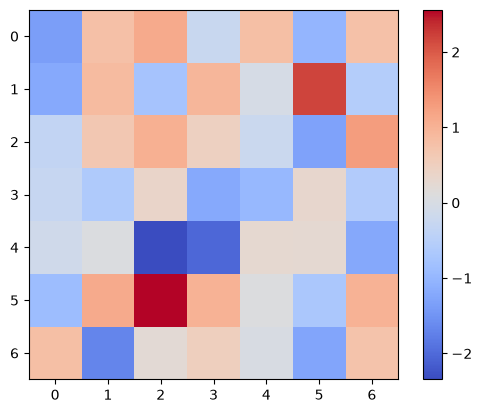

In [114]:
import matplotlib.pyplot as plt
plt.imshow(nn_model.W1[:, 16].detach().reshape(7, 7), cmap="coolwarm")
plt.colorbar()
plt.show()

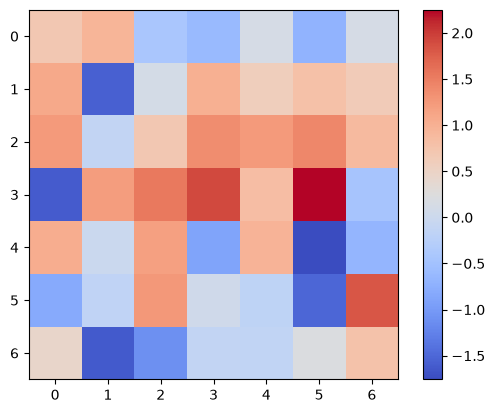

In [115]:
W1_node_2nd = nn_model.W1[:, node_2nd]
plt.imshow(W1_node_2nd.detach().reshape(7, 7), cmap="coolwarm")
plt.colorbar()
plt.show()

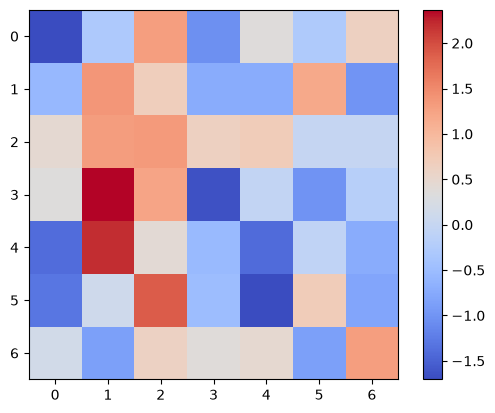

In [116]:
W1_node_3rd = nn_model.W1[:, node_3rd]
plt.imshow(W1_node_3rd.detach().reshape(7, 7), cmap="coolwarm")
plt.colorbar()
plt.show()

まとめると以下のようになります。

これもかなり解釈は難しいのですが、隠れ層の25個の異な

![top 3 hidden nodes](https://raw.githubusercontent.com/HayatoHongo/Everyones_PyTorch/agent/chapter16-images/ColabGPT/images/3top_nodes.png)

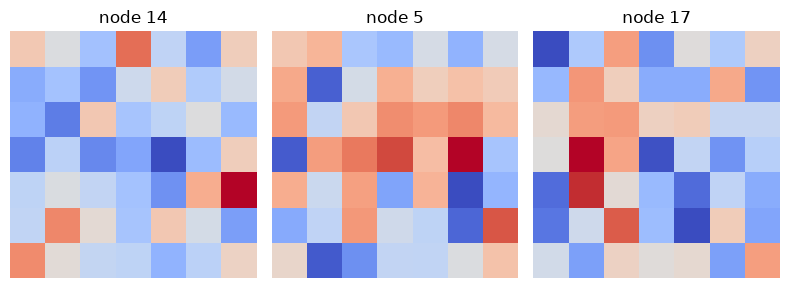

In [117]:
# コードの文法は理解していなくても
# クラス0への寄与が大きい隠れ層ノード上位3つ
# W2 は (隠れ層ノード数, クラス数) = (25, 10)
w = nn_model.W2[:, 0].detach()
nodes = torch.topk(w, 3).indices

fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for ax, node in zip(axes, nodes):
    ax.imshow(nn_model.W1[:, node].detach().reshape(7, 7), cmap="coolwarm")
    ax.set_title(f"node {node.item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 隠れ層をデータと一緒に分析する

重み $W1$ の図だけでは、そのノードが実際に画像で反応するかは分かりません。ここでは、クラス0について **活性化の差** と **出力層での識別への寄与** を合わせて分析します。

ノード $j$ の重要度は、次で定義します。

$$\left(\overline{h_j}_{y=0} - \overline{h_j}_{y\neq0}\right)\left(W2_{j,0}-\operatorname{mean}_{c\neq0}W2_{j,c}\right)$$

前半は「0で特によく反応するか」、後半は「その反応が他クラスより0を押し上げるか」を表します。

クラス0を正解にもつ画像: 100枚
rank  node  重要度    活性化(0)  活性化(他)  W2[ノード,0]  出力差    活性化率
   1    14   +3.686      1.701      0.148       +2.578   +2.373    21.4%
   2     5   +3.064      6.757      4.747       +1.552   +1.524   100.0%
   3    17   +2.794      1.787      0.311       +1.398   +1.894    33.7%
   4    15   +2.437      0.030      0.785       -3.353   -3.226    52.7%
   5    16   +2.080      3.567      0.949       +0.952   +0.795    59.8%
   6     0   +1.883      0.160      1.090       -1.787   -2.025    54.8%


/var/folders/jt/5_z36q1n1sg3hfdfbkzytlyh0000gn/T/ipykernel_46551/3679896042.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


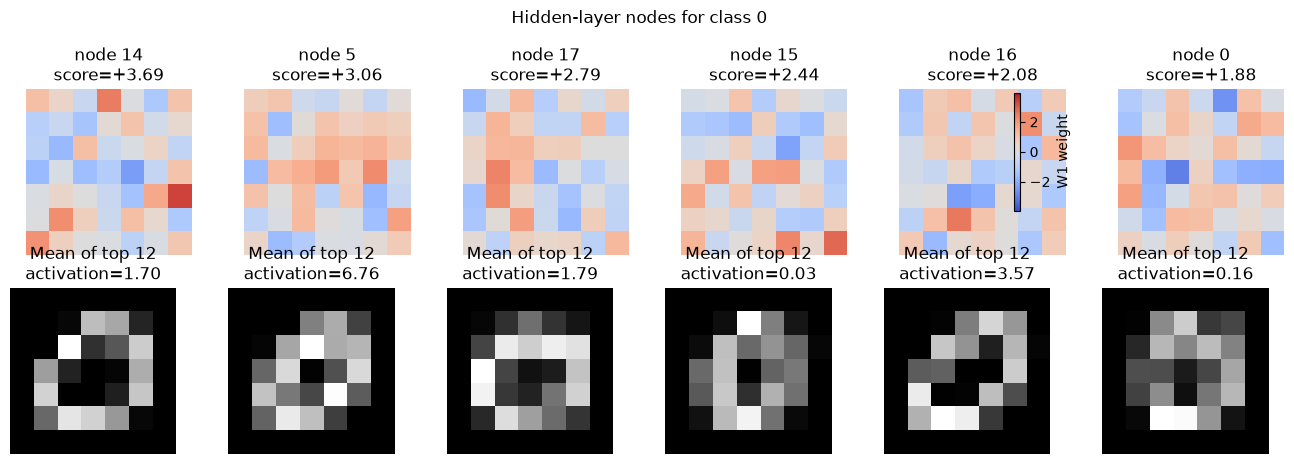

In [118]:
# クラスごとに、実際の活性化と出力層への寄与を調べる
import matplotlib.pyplot as plt

target_class = 0
n_show = 6

with torch.no_grad():
    z = X @ nn_model.W1 + nn_model.b1
    h = torch.relu(z)
    logits = h @ nn_model.W2 + nn_model.b2

    is_target = y == target_class
    mean_h_target = h[is_target].mean(dim=0)
    mean_h_other = h[~is_target].mean(dim=0)
    activation_gap = mean_h_target - mean_h_other

    # クラス0に有利な出力重み。正ならクラス0のスコアを相対的に上げる。
    output_margin = (
        nn_model.W2[:, target_class]
        - nn_model.W2[:, torch.arange(10) != target_class].mean(dim=1)
    )
    importance = activation_gap * output_margin
    active_rate = (h > 0).float().mean(dim=0)
    top_nodes = torch.topk(importance, n_show).indices

print(f"クラス{target_class}を正解にもつ画像: {is_target.sum().item()}枚")
print("rank  node  重要度    活性化(0)  活性化(他)  W2[ノード,0]  出力差    活性化率")
for rank, node in enumerate(top_nodes, start=1):
    j = node.item()
    print(
        f"{rank:>4}  {j:>4}  {importance[j]:>+7.3f}"
        f"  {mean_h_target[j]:>9.3f}  {mean_h_other[j]:>9.3f}"
        f"  {nn_model.W2[j, target_class]:>+11.3f}"
        f"  {output_margin[j]:>+7.3f}  {active_rate[j]:>7.1%}"
    )

# 上段: W1の重み（全ノードで同一の色範囲）。下段: そのノードを強く活性化したクラス0画像の平均。
weight_limit = nn_model.W1.detach().abs().max().item()
fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.5))
for col, node in enumerate(top_nodes):
    j = node.item()
    axes[0, col].imshow(
        nn_model.W1[:, j].detach().reshape(7, 7),
        cmap="coolwarm", vmin=-weight_limit, vmax=weight_limit
    )
    axes[0, col].set_title(f"node {j}\nscore={importance[j]:+.2f}")

    # 「このノードが何を見ているか」を、実際に強く反応した0の画像で確かめる。
    target_indices = torch.where(is_target)[0]
    strongest = target_indices[torch.topk(h[is_target, j], k=min(12, is_target.sum())).indices]
    axes[1, col].imshow(X[strongest].mean(dim=0).reshape(7, 7), cmap="gray")
    axes[1, col].set_title(f"Mean of top 12\nactivation={mean_h_target[j]:.2f}")

    for ax in axes[:, col]:
        ax.axis("off")

fig.colorbar(axes[0, 0].images[0], ax=axes[0], shrink=0.75, label="W1 weight")
plt.suptitle(f"Hidden-layer nodes for class {target_class}", y=1.02)
plt.tight_layout()
plt.show()


node | mean activation (class 0) | mean activation (not class 0) | mean activation (all)
-----|---------------------------|-------------------------------|----------------------
   0 |                     0.160 |                         1.090 |                0.997
   1 |                     0.029 |                         0.051 |                0.049
   2 |                     3.125 |                         2.317 |                2.398
   3 |                     0.348 |                         0.572 |                0.550
   4 |                     0.000 |                         0.010 |                0.009
   5 |                     6.757 |                         4.747 |                4.948
   6 |                     0.008 |                         0.002 |                0.002
   7 |                     3.840 |                         1.603 |                1.826
   8 |                     2.749 |                         3.718 |                3.622
   9 |                     0.2

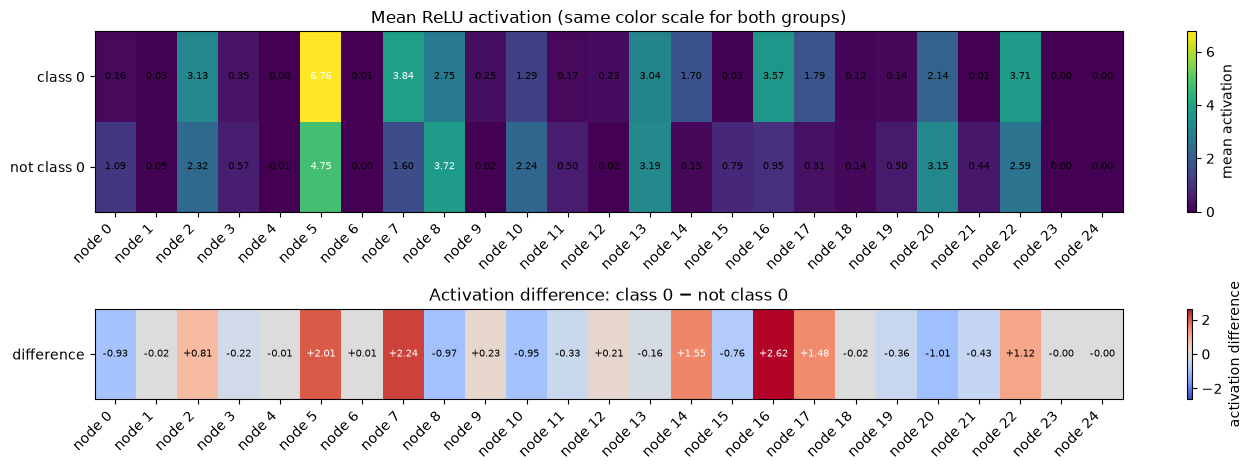

In [119]:
# 1,000枚すべてを入力し、ReLU後の各隠れ層ノードの平均活性化をクラス別に表示する
with torch.no_grad():
    h_all = torch.relu(X @ nn_model.W1 + nn_model.b1)  # shape: (1000, 25)

is_class0 = y == 0
mean_h_class0 = h_all[is_class0].mean(dim=0)       # クラス0の100枚での平均: (25,)
mean_h_nonclass0 = h_all[~is_class0].mean(dim=0)   # クラス0以外の900枚での平均: (25,)
mean_h_all = h_all.mean(dim=0)                     # 全1000枚での平均: (25,)

print("node | mean activation (class 0) | mean activation (not class 0) | mean activation (all)")
print("-----|---------------------------|-------------------------------|----------------------")
for node in range(h_all.shape[1]):
    print(
        f"{node:>4} | {mean_h_class0[node]:>25.3f} |"
        f" {mean_h_nonclass0[node]:>29.3f} | {mean_h_all[node]:>20.3f}"
    )

# 2群の平均は同一の色範囲で描くため、色の濃さを直接比較できる。
import matplotlib.pyplot as plt
mean_values = torch.stack([mean_h_class0, mean_h_nonclass0]).cpu()
shared_max = mean_values.max().item()
activation_gap = (mean_h_class0 - mean_h_nonclass0).cpu()
gap_limit = activation_gap.abs().max().item()

fig, axes = plt.subplots(2, 1, figsize=(14, 4.8), height_ratios=[2, 1])

# 上: class 0 / not class 0 の絶対値。両行で vmin, vmax をそろえる。
image_mean = axes[0].imshow(mean_values, cmap="viridis", vmin=0, vmax=shared_max, aspect="auto")
axes[0].set_yticks([0, 1], ["class 0", "not class 0"])
axes[0].set_xticks(range(25), [f"node {j}" for j in range(25)], rotation=45, ha="right")
axes[0].set_title("Mean ReLU activation (same color scale for both groups)")
for row in range(2):
    for node in range(25):
        text_color = "white" if mean_values[row, node] > shared_max * 0.55 else "black"
        axes[0].text(node, row, f"{mean_values[row, node]:.2f}", ha="center", va="center", fontsize=7, color=text_color)
fig.colorbar(image_mean, ax=axes[0], label="mean activation")

# 下: class 0 - not class 0。赤は0でより強く反応し、青は0以外でより強く反応する。
image_gap = axes[1].imshow(activation_gap.unsqueeze(0), cmap="coolwarm", vmin=-gap_limit, vmax=gap_limit, aspect="auto")
axes[1].set_yticks([0], ["difference"])
axes[1].set_xticks(range(25), [f"node {j}" for j in range(25)], rotation=45, ha="right")
axes[1].set_title("Activation difference: class 0 − not class 0")
for node in range(25):
    text_color = "white" if abs(activation_gap[node]) > gap_limit * 0.55 else "black"
    axes[1].text(node, 0, f"{activation_gap[node]:+.2f}", ha="center", va="center", fontsize=7, color=text_color)
fig.colorbar(image_gap, ax=axes[1], label="activation difference")

plt.tight_layout()
plt.show()


sample=3, 正解=0, 予測=0
クラス0のlogit = 17.561
 1. node  5: h=8.187, W2=+1.552, 寄与=+12.705
 2. node 16: h=4.948, W2=+0.952, 寄与=+4.711
 3. node  2: h=4.207, W2=+0.892, 寄与=+3.751
 4. node 22: h=3.574, W2=+0.984, 寄与=+3.518
 5. node 14: h=1.312, W2=+2.578, 寄与=+3.384
 6. node 17: h=1.532, W2=+1.398, 寄与=+2.142
 7. node  7: h=8.686, W2=+0.076, 寄与=+0.659
 8. node  3: h=0.506, W2=+0.112, 寄与=+0.057
 9. node 12: h=0.000, W2=+0.545, 寄与=+0.000
10. node  1: h=0.000, W2=+0.026, 寄与=+0.000


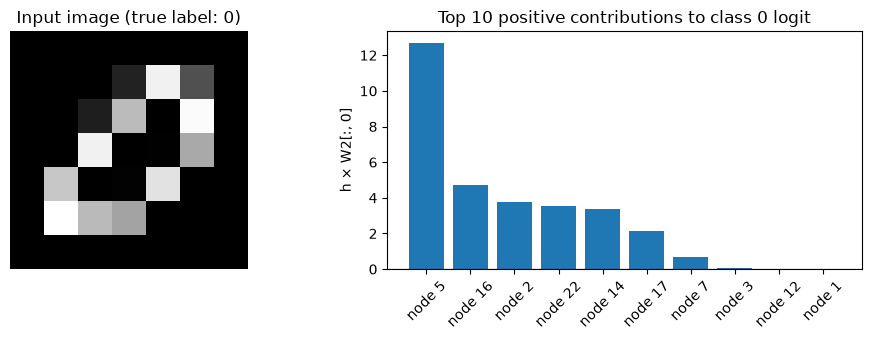

In [120]:
# 1枚の画像について、クラス0のスコアを実際に押し上げたノードを確認する
# 寄与は h_j * W2[j, 0]。ReLUで h_j が0なら、W1がどんな形でもこの画像には寄与しない。
sample_index = torch.where(is_target)[0][0].item()
contribution = h[sample_index] * nn_model.W2[:, target_class]
top_contributors = torch.topk(contribution, 10).indices

print(f"sample={sample_index}, 正解={y[sample_index].item()}, 予測={logits[sample_index].argmax().item()}")
print(f"クラス{target_class}のlogit = {logits[sample_index, target_class].item():.3f}")
for rank, node in enumerate(top_contributors, start=1):
    j = node.item()
    print(f"{rank:>2}. node {j:>2}: h={h[sample_index, j]:.3f}, W2={nn_model.W2[j, target_class]:+.3f}, 寄与={contribution[j]:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].imshow(X[sample_index].reshape(7, 7), cmap="gray")
axes[0].set_title(f"Input image (true label: {y[sample_index].item()})")
axes[0].axis("off")
axes[1].bar(range(len(top_contributors)), contribution[top_contributors].detach())
axes[1].set_xticks(range(len(top_contributors)), [f"node {j.item()}" for j in top_contributors], rotation=45)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel(f"h × W2[:, {target_class}]")
axes[1].set_title(f"Top 10 positive contributions to class {target_class} logit")
plt.tight_layout()
plt.show()


クラス0の画像数: 100枚
クラス0 logitへの平均寄与（上位10ノード）
 1. node  5: 平均h=6.757, W2=+1.552, 平均寄与=+10.487
 2. node 14: 平均h=1.701, W2=+2.578, 平均寄与=+4.387
 3. node 22: 平均h=3.705, W2=+0.984, 平均寄与=+3.648
 4. node 16: 平均h=3.567, W2=+0.952, 平均寄与=+3.396
 5. node  2: 平均h=3.125, W2=+0.892, 平均寄与=+2.786
 6. node 17: 平均h=1.787, W2=+1.398, 平均寄与=+2.497
 7. node 10: 平均h=1.291, W2=+1.207, 平均寄与=+1.559
 8. node 20: 平均h=2.139, W2=+0.148, 平均寄与=+0.316
 9. node  7: 平均h=3.840, W2=+0.076, 平均寄与=+0.291
10. node 12: 平均h=0.231, W2=+0.545, 平均寄与=+0.126


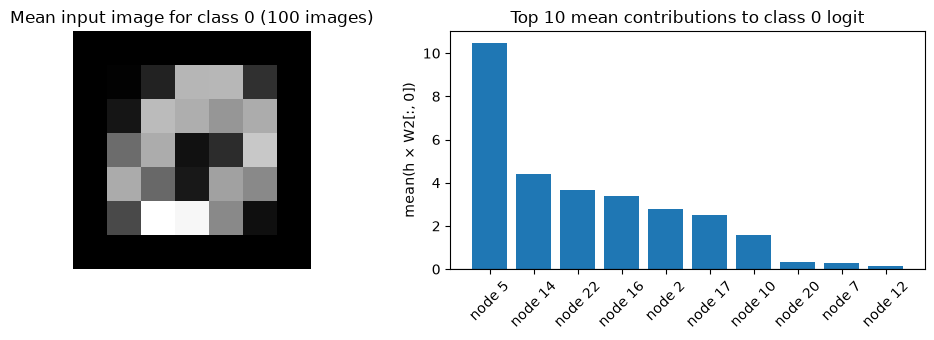

In [121]:
# クラス0の100枚について、各隠れ層ノードのクラス0 logit への平均寄与を調べる
# 各画像での寄与は h_j × W2[j, 0]。ここでは100枚分を平均する。
target_class = 0

with torch.no_grad():
    h_all = torch.relu(X @ nn_model.W1 + nn_model.b1)
    is_class0 = y == target_class

    # shape: (100, 25)。各行は1枚、各列は隠れ層ノードの寄与。
    contributions_class0 = h_all[is_class0] * nn_model.W2[:, target_class]
    mean_contribution = contributions_class0.mean(dim=0)
    mean_activation = h_all[is_class0].mean(dim=0)
    top_contributors = torch.topk(mean_contribution, 10).indices

print(f"クラス{target_class}の画像数: {is_class0.sum().item()}枚")
print(f"クラス{target_class} logitへの平均寄与（上位10ノード）")
for rank, node in enumerate(top_contributors, start=1):
    j = node.item()
    print(
        f"{rank:>2}. node {j:>2}: 平均h={mean_activation[j]:.3f}, "
        f"W2={nn_model.W2[j, target_class]:+.3f}, 平均寄与={mean_contribution[j]:+.3f}"
    )

# 左: クラス0の100枚の平均画像。右: その画像群に対するノード別の平均寄与。
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].imshow(X[is_class0].mean(dim=0).reshape(7, 7), cmap="gray")
axes[0].set_title("Mean input image for class 0 (100 images)")
axes[0].axis("off")

axes[1].bar(range(len(top_contributors)), mean_contribution[top_contributors].detach())
axes[1].set_xticks(
    range(len(top_contributors)),
    [f"node {j.item()}" for j in top_contributors],
    rotation=45
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel(f"mean(h × W2[:, {target_class}])")
axes[1].set_title(f"Top 10 mean contributions to class {target_class} logit")
plt.tight_layout()
plt.show()


/var/folders/jt/5_z36q1n1sg3hfdfbkzytlyh0000gn/T/ipykernel_46551/1479739139.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


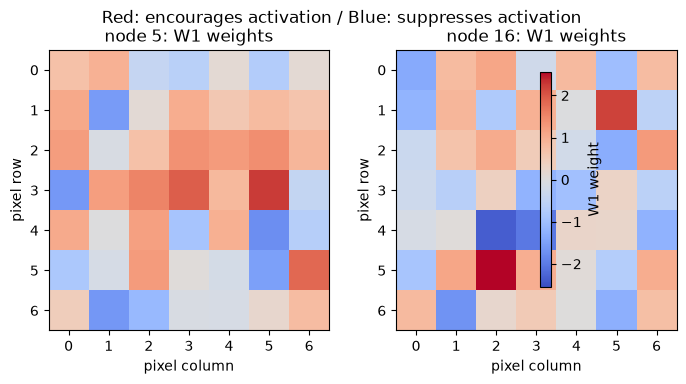

In [122]:
# node 5 と node 16 が、7×7画像のどの画素に反応するかを簡易表示する
import matplotlib.pyplot as plt

nodes_to_show = [5, 16]
# 2枚で同じ色範囲にし、重みの大きさを直接比較できるようにする。
weight_limit = nn_model.W1[:, nodes_to_show].detach().abs().max().item()

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
for ax, node in zip(axes, nodes_to_show):
    image = ax.imshow(
        nn_model.W1[:, node].detach().reshape(7, 7),
        cmap="coolwarm", vmin=-weight_limit, vmax=weight_limit
    )
    ax.set_title(f"node {node}: W1 weights")
    ax.set_xlabel("pixel column")
    ax.set_ylabel("pixel row")
    ax.set_xticks(range(7))
    ax.set_yticks(range(7))

fig.colorbar(image, ax=axes, shrink=0.8, label="W1 weight")
plt.suptitle("Red: encourages activation / Blue: suppresses activation")
plt.tight_layout()
plt.show()


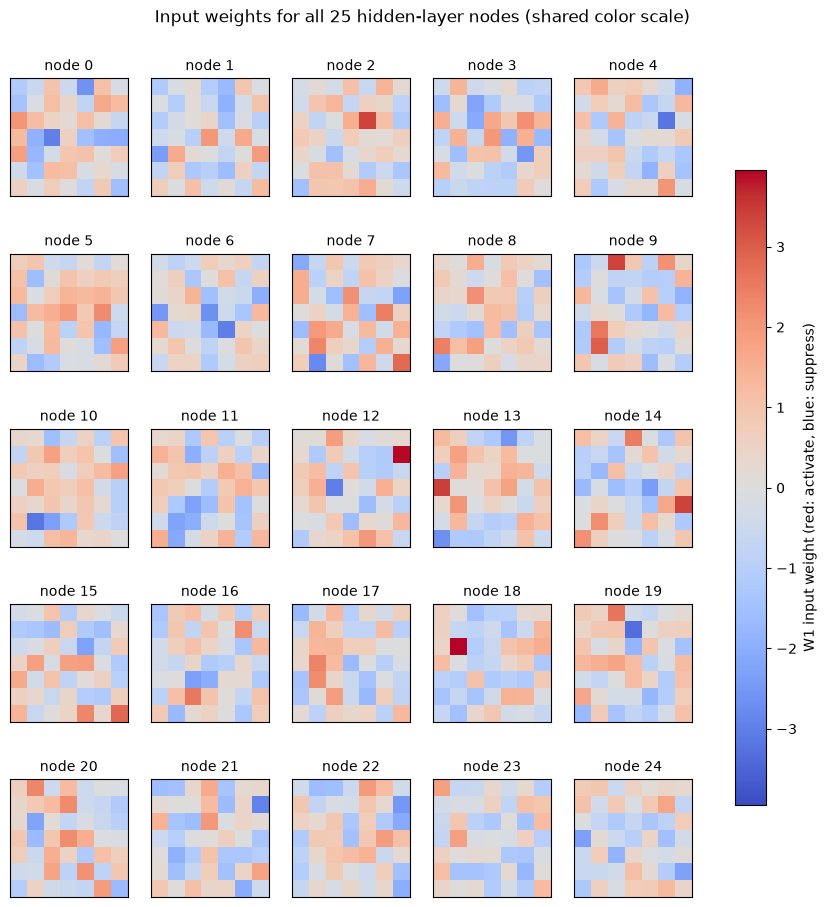

In [123]:
# node 0〜24 の入力重み W1 を、共通のカラーバーで比較する
import matplotlib.pyplot as plt

# 全25ノード・全49画素での最大絶対値を使うため、全図で色の意味が同じになる。
weight_limit = nn_model.W1.detach().abs().max().item()

fig, axes = plt.subplots(5, 5, figsize=(11, 11))
for node, ax in enumerate(axes.flat):
    image = ax.imshow(
        nn_model.W1[:, node].detach().reshape(7, 7),
        cmap="coolwarm",
        vmin=-weight_limit,
        vmax=weight_limit
    )
    ax.set_title(f"node {node}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(
    image,
    ax=axes.ravel().tolist(),
    shrink=0.75,
    label="W1 input weight (red: activate, blue: suppress)"
)
fig.suptitle("Input weights for all 25 hidden-layer nodes (shared color scale)", y=0.93)
plt.show()


## 1枚のクラス0画像がモデル内を通る様子

入力49個 → ReLU前の隠れ層25個 → ReLU後の隠れ層25個 → 出力10個を、すべて横一列のヒートマップで確認します。

sample=3, true label=0, predicted label=0


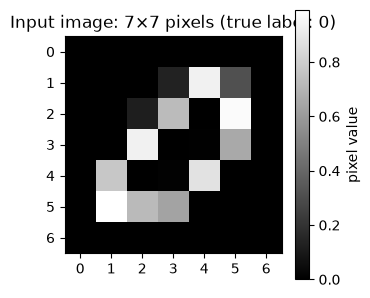

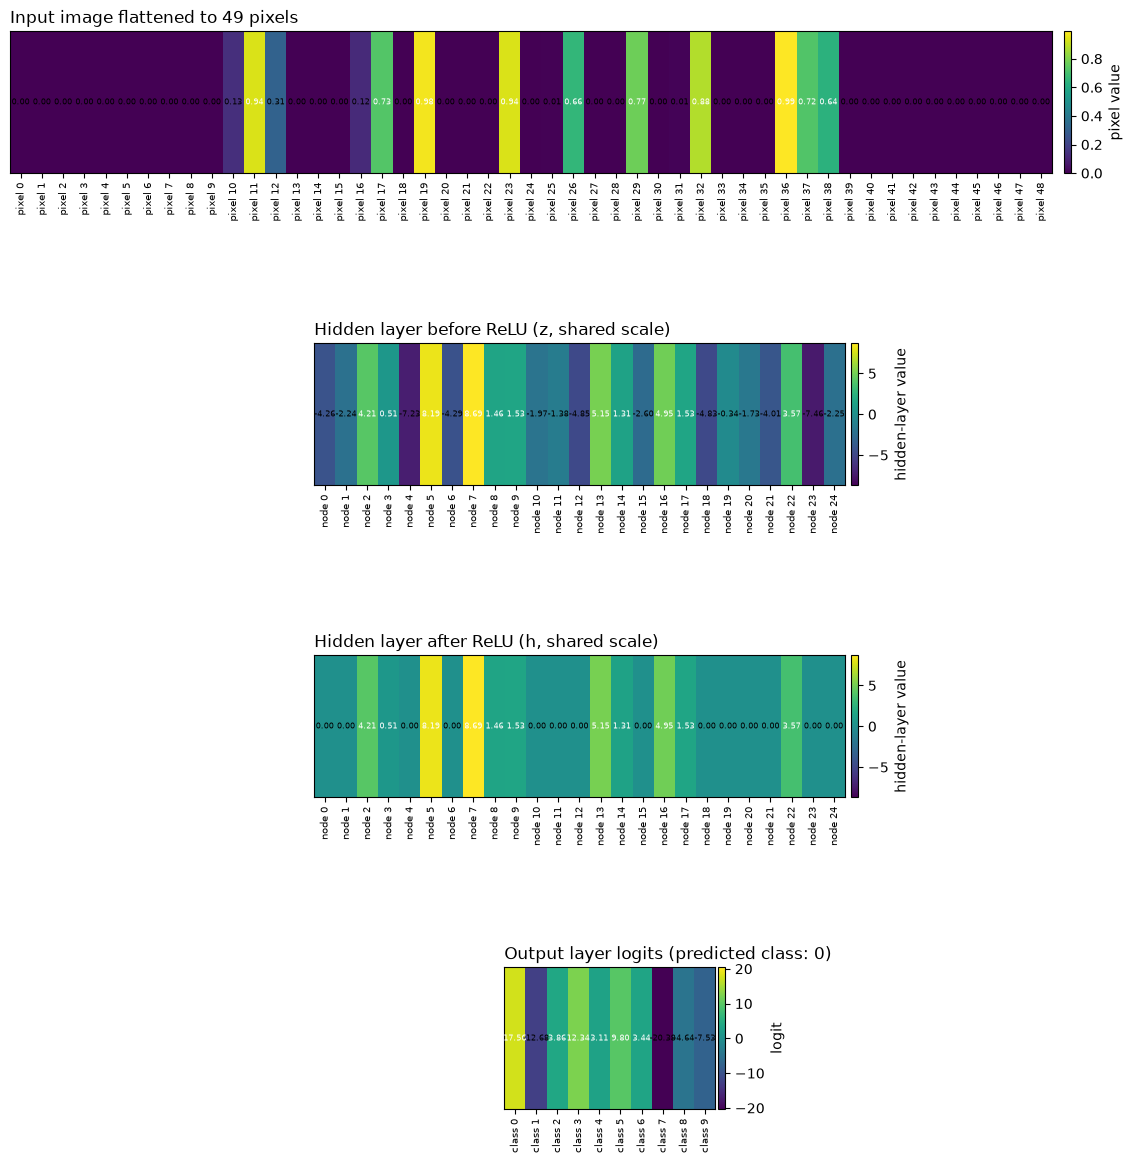

In [124]:
# 正解ラベル0の最初の画像を、訓練済みモデルに入力して各段階の値を可視化する
import matplotlib.pyplot as plt

sample_index = torch.where(y == 0)[0][0].item()  # 別の0を見たい場合は、この番号を変更する
x_one = X[sample_index]

with torch.no_grad():
    z_one = x_one @ nn_model.W1 + nn_model.b1       # ReLU前: (25,)
    h_one = torch.relu(z_one)                       # ReLU後: (25,)
    logits_one = h_one @ nn_model.W2 + nn_model.b2   # 出力層: (10,)

predicted_class = logits_one.argmax().item()
print(f"sample={sample_index}, true label={y[sample_index].item()}, predicted label={predicted_class}")

def draw_vector_heatmap(ax, values, title, cmap, vmin, vmax, xlabels, colorbar_label):
    """1次元テンソルを、値と色を対応させた横一列のヒートマップとして描く。"""
    values = values.detach().cpu()
    image = ax.imshow(values.unsqueeze(0), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title, loc="left")
    ax.set_yticks([])
    ax.set_xticks(range(len(values)), xlabels, rotation=90, fontsize=7)
    threshold = (vmin + vmax) / 2
    for index, value in enumerate(values):
        text_color = "white" if value.item() > threshold else "black"
        ax.text(index, 0, f"{value.item():.2f}", ha="center", va="center", fontsize=6, color=text_color)
    fig.colorbar(image, ax=ax, pad=0.01, label=colorbar_label)

# ReLU前・ReLU後は同じスケールで比較する。負の値も含め、0を中心とした対称範囲にする。
hidden_limit = max(z_one.abs().max().item(), h_one.abs().max().item())
logit_limit = logits_one.abs().max().item()
input_limit = x_one.max().item()

# 49個に並べる前の、元の7×7白黒画像も表示する。
fig_input, ax_input = plt.subplots(figsize=(3.5, 3.5))
image_input = ax_input.imshow(x_one.reshape(7, 7), cmap="gray", vmin=0, vmax=input_limit)
ax_input.set_title(f"Input image: 7×7 pixels (true label: {y[sample_index].item()})")
ax_input.set_xticks(range(7))
ax_input.set_yticks(range(7))
fig_input.colorbar(image_input, ax=ax_input, label="pixel value")
plt.show()

# 49 / 25 / 25 / 10 個という要素数に応じて、横幅も変える。
# 行間を明示的に大きく取る。タイトル・縦向きラベル・カラーバーが隣の段と重ならない。
fig = plt.figure(figsize=(16, 14))
grid = fig.add_gridspec(4, 98, hspace=1.2)  # 2倍にして、25個・10個の段も正確に中央揃えにする
axes = [
    fig.add_subplot(grid[0, :98]),   # 入力: 49個（各値は2列分）
    fig.add_subplot(grid[1, 24:74]), # ReLU前: 25個（中央揃え）
    fig.add_subplot(grid[2, 24:74]), # ReLU後: 25個（中央揃え）
    fig.add_subplot(grid[3, 39:59]), # 出力: 10個（中央揃え）
]
draw_vector_heatmap(
    axes[0], x_one, "Input image flattened to 49 pixels", "viridis", 0, input_limit,
    [f"pixel {i}" for i in range(49)], "pixel value"
)
draw_vector_heatmap(
    axes[1], z_one, "Hidden layer before ReLU (z, shared scale)", "viridis", -hidden_limit, hidden_limit,
    [f"node {i}" for i in range(25)], "hidden-layer value"
)
draw_vector_heatmap(
    axes[2], h_one, "Hidden layer after ReLU (h, shared scale)", "viridis", -hidden_limit, hidden_limit,
    [f"node {i}" for i in range(25)], "hidden-layer value"
)
draw_vector_heatmap(
    axes[3], logits_one, f"Output layer logits (predicted class: {predicted_class})", "viridis", -logit_limit, logit_limit,
    [f"class {i}" for i in range(10)], "logit"
)
plt.show()


## 1枚の画像が横方向に流れる様子

同じ計算を、左から右へ流れる形で確認します。

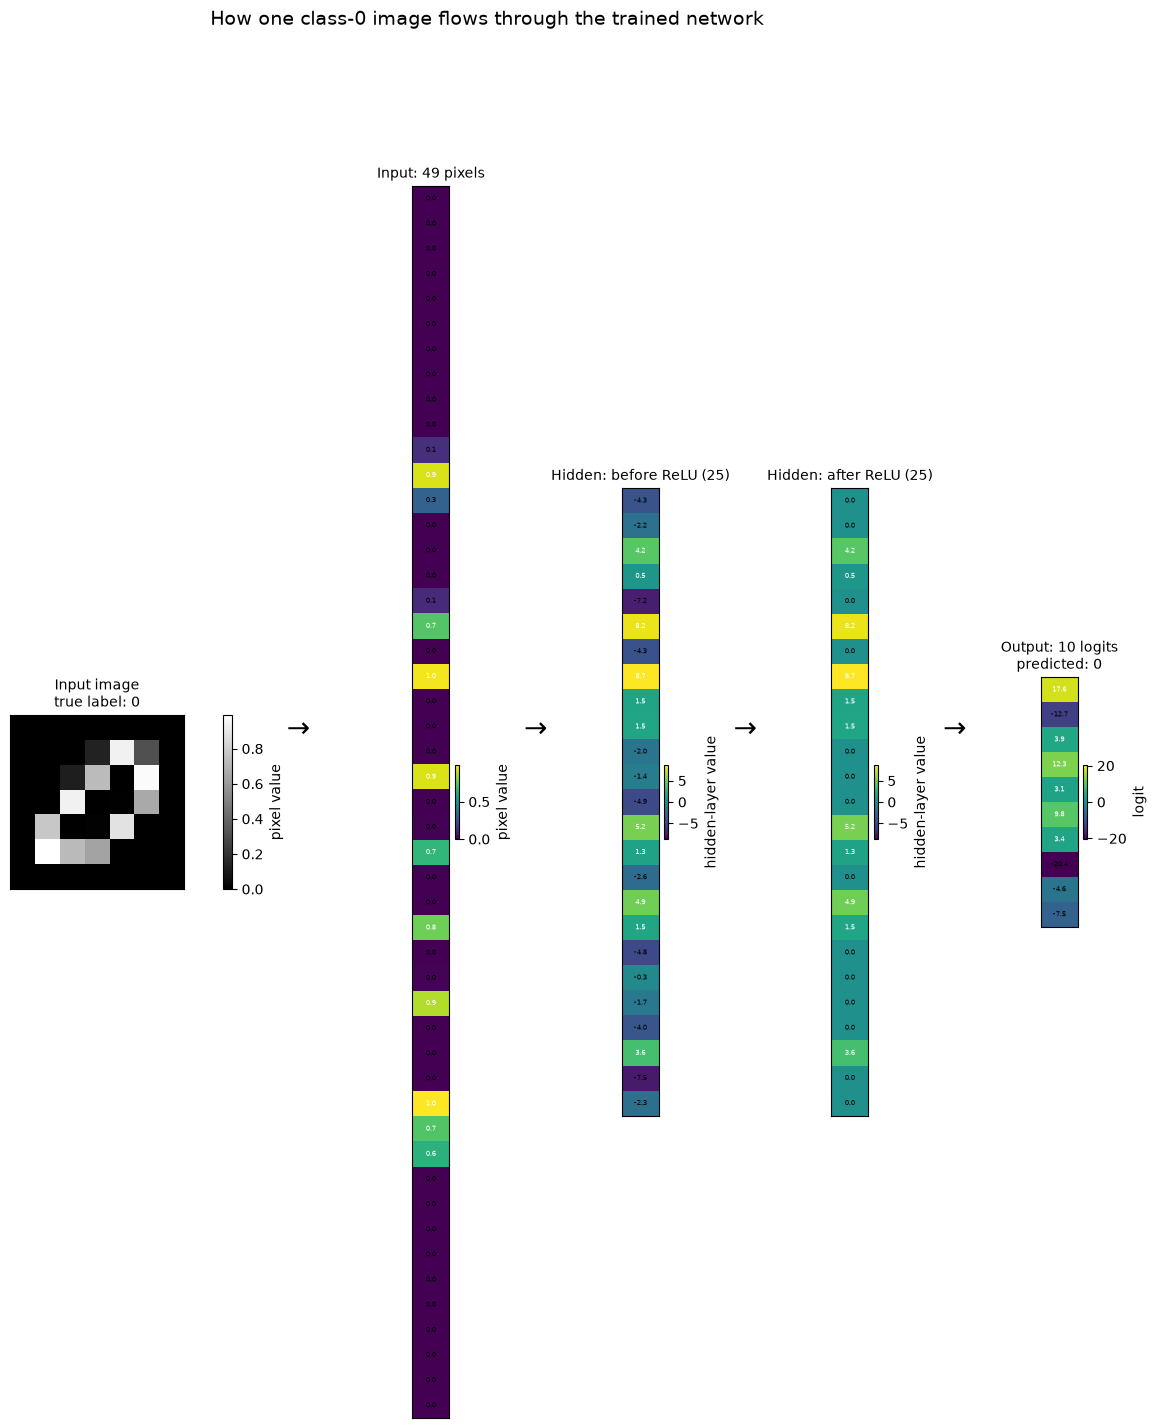

In [125]:
# 1枚のクラス0画像について、入力から出力までを横方向に並べて可視化する
import matplotlib.pyplot as plt

sample_index = torch.where(y == 0)[0][0].item()
x_one = X[sample_index]
with torch.no_grad():
    z_one = x_one @ nn_model.W1 + nn_model.b1
    h_one = torch.relu(z_one)
    logits_one = h_one @ nn_model.W2 + nn_model.b2

input_limit = x_one.max().item()
hidden_limit = max(z_one.abs().max().item(), h_one.abs().max().item())
logit_limit = logits_one.abs().max().item()
predicted_class = logits_one.argmax().item()

def draw_vertical_vector(ax, values, title, vmin, vmax, colorbar_label):
    values = values.detach().cpu()
    image = ax.imshow(values.unsqueeze(1), cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    threshold = (vmin + vmax) / 2
    for index, value in enumerate(values):
        text_color = "white" if value.item() > threshold else "black"
        ax.text(0, index, f"{value.item():.1f}", ha="center", va="center", fontsize=5, color=text_color)
    fig.colorbar(image, ax=ax, orientation="vertical", pad=0.12, fraction=0.08, label=colorbar_label)

# 層は左から右へ流し、各層の値は縦に積む。高さは要素数に比例させ、短い列は中央揃えにする。
fig = plt.figure(figsize=(15, 16))
grid = fig.add_gridspec(98, 5, width_ratios=[14, 2, 2, 2, 2], wspace=1.6)
axes = [
    fig.add_subplot(grid[42:56, 0]),  # 元画像: 7×7を14×14の領域に置く
    fig.add_subplot(grid[:, 1]),      # 入力49個
    fig.add_subplot(grid[24:74, 2]),  # 隠れ層25個（中央揃え）
    fig.add_subplot(grid[24:74, 3]),  # 隠れ層25個（中央揃え）
    fig.add_subplot(grid[39:59, 4]),  # 出力10個（中央揃え）
]

input_image = axes[0].imshow(x_one.reshape(7, 7), cmap="gray", vmin=0, vmax=input_limit)
axes[0].set_title(f"Input image\ntrue label: {y[sample_index].item()}", fontsize=10)
axes[0].set_xticks([])
axes[0].set_yticks([])
fig.colorbar(input_image, ax=axes[0], orientation="vertical", pad=0.12, fraction=0.08, label="pixel value")

draw_vertical_vector(axes[1], x_one, "Input: 49 pixels", 0, input_limit, "pixel value")
draw_vertical_vector(axes[2], z_one, "Hidden: before ReLU (25)", -hidden_limit, hidden_limit, "hidden-layer value")
draw_vertical_vector(axes[3], h_one, "Hidden: after ReLU (25)", -hidden_limit, hidden_limit, "hidden-layer value")
draw_vertical_vector(axes[4], logits_one, f"Output: 10 logits\npredicted: {predicted_class}", -logit_limit, logit_limit, "logit")

# 描画位置を確定してから、段階の間に矢印を置く。
fig.canvas.draw()
for left, right in zip(axes[:-1], axes[1:]):
    left_box = left.get_position()
    right_box = right.get_position()
    fig.text((left_box.x1 + right_box.x0) / 2, 0.54, "→", ha="center", va="center", fontsize=20)

fig.suptitle("How one class-0 image flows through the trained network", fontsize=14, y=0.99)
plt.show()


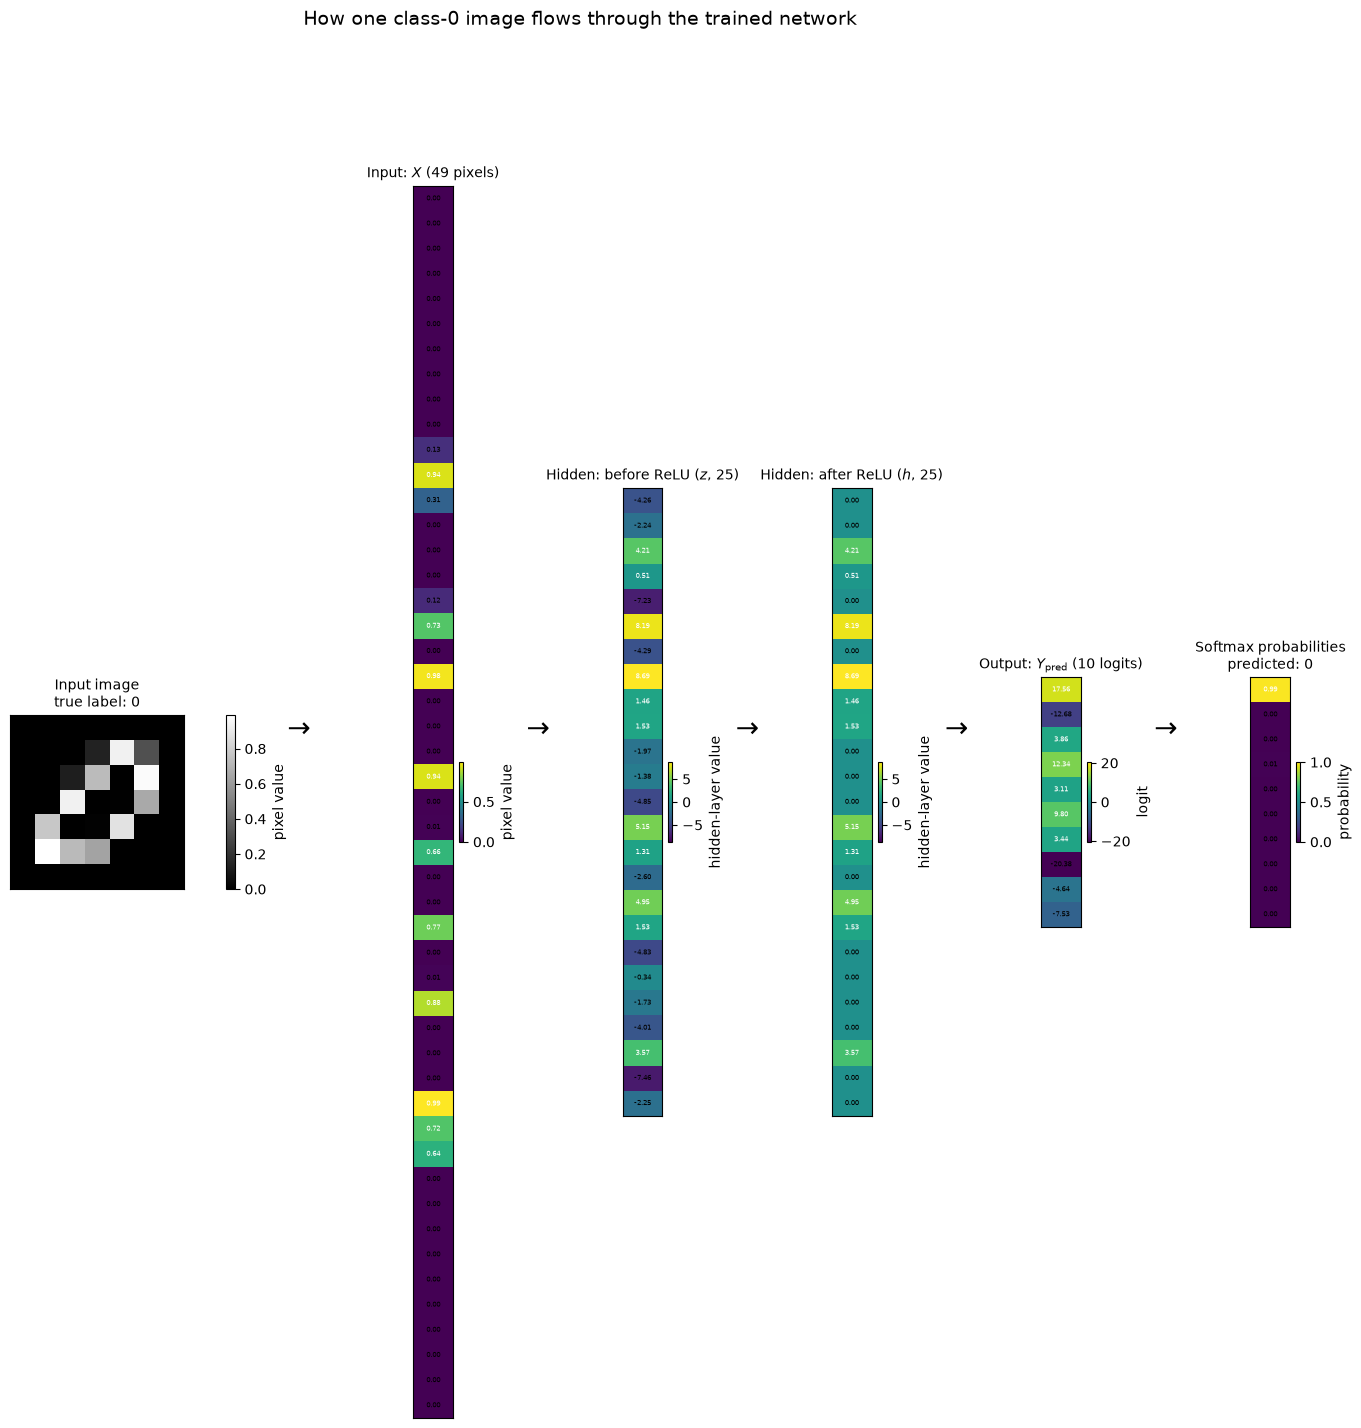

In [126]:
# 直前の横方向フローに、Softmaxで確率へ変換した最終結果を追加する
import matplotlib.pyplot as plt

sample_index = torch.where(y == 0)[0][0].item()
x_one = X[sample_index]
with torch.no_grad():
    z_one = x_one @ nn_model.W1 + nn_model.b1
    h_one = torch.relu(z_one)
    logits_one = h_one @ nn_model.W2 + nn_model.b2
    probabilities_one = torch.softmax(logits_one, dim=0)

input_limit = x_one.max().item()
hidden_limit = max(z_one.abs().max().item(), h_one.abs().max().item())
logit_limit = logits_one.abs().max().item()
predicted_class = logits_one.argmax().item()

def draw_vertical_vector(ax, values, title, vmin, vmax, colorbar_label):
    values = values.detach().cpu()
    image = ax.imshow(values.unsqueeze(1), cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    threshold = (vmin + vmax) / 2
    for index, value in enumerate(values):
        text_color = "white" if value.item() > threshold else "black"
        ax.text(0, index, f"{value.item():.2f}", ha="center", va="center", fontsize=5, color=text_color)
    fig.colorbar(image, ax=ax, orientation="vertical", pad=0.12, fraction=0.08, label=colorbar_label)

# 左から右へ流し、各層の値は縦に積む。短い列は中央揃えにする。
fig = plt.figure(figsize=(18, 16))
grid = fig.add_gridspec(98, 6, width_ratios=[14, 2, 2, 2, 2, 2], wspace=1.6)
axes = [
    fig.add_subplot(grid[42:56, 0]),  # 元画像
    fig.add_subplot(grid[:, 1]),      # 入力49個
    fig.add_subplot(grid[24:74, 2]),  # ReLU前25個
    fig.add_subplot(grid[24:74, 3]),  # ReLU後25個
    fig.add_subplot(grid[39:59, 4]),  # logit 10個
    fig.add_subplot(grid[39:59, 5]),  # 確率10個
]

input_image = axes[0].imshow(x_one.reshape(7, 7), cmap="gray", vmin=0, vmax=input_limit)
axes[0].set_title(f"Input image\ntrue label: {y[sample_index].item()}", fontsize=10)
axes[0].set_xticks([])
axes[0].set_yticks([])
fig.colorbar(input_image, ax=axes[0], orientation="vertical", pad=0.12, fraction=0.08, label="pixel value")

draw_vertical_vector(axes[1], x_one, r"Input: $X$ (49 pixels)", 0, input_limit, "pixel value")
draw_vertical_vector(axes[2], z_one, r"Hidden: before ReLU ($z$, 25)", -hidden_limit, hidden_limit, "hidden-layer value")
draw_vertical_vector(axes[3], h_one, r"Hidden: after ReLU ($h$, 25)", -hidden_limit, hidden_limit, "hidden-layer value")
draw_vertical_vector(axes[4], logits_one, r"Output: $Y_{\mathrm{pred}}$ (10 logits)", -logit_limit, logit_limit, "logit")
draw_vertical_vector(axes[5], probabilities_one, f"Softmax probabilities\npredicted: {predicted_class}", 0, 1, "probability")

# 描画位置を確定してから、段階の間に矢印を置く。
fig.canvas.draw()
for left, right in zip(axes[:-1], axes[1:]):
    left_box = left.get_position()
    right_box = right.get_position()
    fig.text((left_box.x1 + right_box.x0) / 2, 0.54, "→", ha="center", va="center", fontsize=20)

fig.suptitle("How one class-0 image flows through the trained network", fontsize=14, y=0.99)
plt.show()


In [127]:
# 層を2枚に増やして、間に ReLU を挟む（はじめてのニューラルネットワーク！）
import torch
# torch.nn は何度も使うので、ここからは nn という短い名前で呼ぶ
import torch.nn as nn
# torch.optim は何度も使うので、ここからは optim という短い名前で呼ぶ
import torch.optim as optim


data = torch.load("mnist_7x7_shuffled_difficult_1000.pt")
X = data["X"]  # (1000, 49)
y = data["y"]  # 各クラス100枚
Y = data["Y"]  # (1000, 10)


torch.manual_seed(0)

########## NEW ##########
# 49 → 25 → 10 と、2段階で変換する
# ReLU: マイナスの値を0にする関数。これを挟むと「直線では分けられない模様」も学習できる
# モデルのクラスは主に、初期化メソッドと、順伝播のメソッドの2つのメソッドを持ちます。
class NeuralNetwork():
    # クラスの初期化メソッドは、変数を登録します。
    def __init__(self):
        self.W1 = torch.randn(49, 25, requires_grad=True)
        self.b1 = torch.zeros(25, requires_grad=True) 
        self.W2 = torch.randn(25, 10, requires_grad=True) # TODO: 出力=式
        self.b2 = torch.zeros(10, requires_grad=True) # TODO: 出力=式

    # 順伝播のメソッドは、入力を受け取り、出力を返します。
    def forward(self, X):
        # 予測する
        z = X @ self.W1 + self.b1
        h = torch.relu(z) # TODO: 出力 = 関数(引数)
        Y_pred = h @ self.W2 + self.b2 # TODO: 出力 = 式
        return Y_pred


model = NeuralNetwork()
########## NEW ##########
"""DELETE
model = nn.Linear(784, 10, bias=False)
"""

criterion = nn.CrossEntropyLoss(reduction="mean")
########## NEW ##########
optimizer = optim.SGD(model.parameters(), lr=0.1)
########## NEW ##########
"""DELETE
optimizer = optim.SGD([model.weight], lr=1.0)
"""


num_epochs = 10000
for epoch in range(num_epochs):

    # 予測する
    Y_pred = model.forward(X)

    # 損失を計算する
    loss = criterion.forward(Y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print("epoch", epoch, "loss", loss)

Y_pred = model.forward(X)
Y_pred_prob = torch.softmax(Y_pred, dim=1)
Y_pred_class = torch.argmax(Y_pred_prob, dim=1)
num_correct = torch.sum(Y_pred_class == y)
accuracy = num_correct / len(y)
print("正解率:", accuracy)


AttributeError: 'NeuralNetwork' object has no attribute 'parameters'